# I. EDA & Transform

In [1]:
import pandas as pd
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df =pd.read_csv('train.csv', delimiter=',', index_col=0)

In [3]:
df

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103899,94171,Female,disloyal Customer,23,Business travel,Eco,192,2,1,2,...,2,3,1,4,2,3,2,3,0.0,neutral or dissatisfied
103900,73097,Male,Loyal Customer,49,Business travel,Business,2347,4,4,4,...,5,5,5,5,5,5,4,0,0.0,satisfied
103901,68825,Male,disloyal Customer,30,Business travel,Business,1995,1,1,1,...,4,3,2,4,5,5,4,7,14.0,neutral or dissatisfied
103902,54173,Female,disloyal Customer,22,Business travel,Eco,1000,1,1,1,...,1,4,5,1,5,4,1,0,0.0,neutral or dissatisfied


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 103904 entries, 0 to 103903
Data columns (total 24 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   id                                 103904 non-null  int64  
 1   Gender                             103904 non-null  object 
 2   Customer Type                      103904 non-null  object 
 3   Age                                103904 non-null  int64  
 4   Type of Travel                     103904 non-null  object 
 5   Class                              103904 non-null  object 
 6   Flight Distance                    103904 non-null  int64  
 7   Inflight wifi service              103904 non-null  int64  
 8   Departure/Arrival time convenient  103904 non-null  int64  
 9   Ease of Online booking             103904 non-null  int64  
 10  Gate location                      103904 non-null  int64  
 11  Food and drink                     103904 no

In [5]:
missing_counts = df.isnull().sum()
missing_percentage = (missing_counts / len(df) * 100)
missing_summary = pd.DataFrame ({'missing_counts': missing_counts, 'missing_percentage': missing_percentage})
print(missing_summary)

                                   missing_counts  missing_percentage
id                                              0            0.000000
Gender                                          0            0.000000
Customer Type                                   0            0.000000
Age                                             0            0.000000
Type of Travel                                  0            0.000000
Class                                           0            0.000000
Flight Distance                                 0            0.000000
Inflight wifi service                           0            0.000000
Departure/Arrival time convenient               0            0.000000
Ease of Online booking                          0            0.000000
Gate location                                   0            0.000000
Food and drink                                  0            0.000000
Online boarding                                 0            0.000000
Seat comfort        

In [6]:
df.duplicated().sum() # Result: No data duplicates

np.int64(0)

In [7]:
df = df.rename(columns={'Customer Type': 'Loyalty Status'})

In [8]:
missing_counts = df.isnull().sum()
missing_percentage = (missing_counts / len(df) * 100)
missing_summary = pd.DataFrame ({'missing_counts': missing_counts, 'missing_percentage': missing_percentage})
print(missing_summary)

                                   missing_counts  missing_percentage
id                                              0            0.000000
Gender                                          0            0.000000
Loyalty Status                                  0            0.000000
Age                                             0            0.000000
Type of Travel                                  0            0.000000
Class                                           0            0.000000
Flight Distance                                 0            0.000000
Inflight wifi service                           0            0.000000
Departure/Arrival time convenient               0            0.000000
Ease of Online booking                          0            0.000000
Gate location                                   0            0.000000
Food and drink                                  0            0.000000
Online boarding                                 0            0.000000
Seat comfort        

In [9]:
df['Loyalty Status'].unique()

array(['Loyal Customer', 'disloyal Customer'], dtype=object)

In [10]:
df['Loyalty Status'] = df['Loyalty Status'].replace('disloyal Customer', 0)
df['Loyalty Status'] = df['Loyalty Status'].replace('Loyal Customer', 1)

C:\Users\User\AppData\Local\Temp\ipykernel_21068\2621221797.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Loyalty Status'] = df['Loyalty Status'].replace('Loyal Customer', 1)


In [11]:
df

,id,Gender,Loyalty Status,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,70172,Male,1,13,Personal Travel,Eco Plus,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,5047,Male,0,25,Business travel,Business,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,110028,Female,1,26,Business travel,Business,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,24026,Female,1,25,Business travel,Business,562,2,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,119299,Male,1,61,Business travel,Business,214,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103899,94171,Female,0,23,Business travel,Eco,192,2,1,2,...,2,3,1,4,2,3,2,3,0.0,neutral or dissatisfied
103900,73097,Male,1,49,Business travel,Business,2347,4,4,4,...,5,5,5,5,5,5,4,0,0.0,satisfied
103901,68825,Male,0,30,Business travel,Business,1995,1,1,1,...,4,3,2,4,5,5,4,7,14.0,neutral or dissatisfied
103902,54173,Female,0,22,Business travel,Eco,1000,1,1,1,...,1,4,5,1,5,4,1,0,0.0,neutral or dissatisfied


In [12]:
df['satisfaction'].unique()

array(['neutral or dissatisfied', 'satisfied'], dtype=object)

In [13]:
df['satisfaction'] = df['satisfaction'].replace('neutral or dissatisfied', 0)
df['satisfaction'] = df['satisfaction'].replace('satisfied', 1)

C:\Users\User\AppData\Local\Temp\ipykernel_21068\3399308646.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['satisfaction'] = df['satisfaction'].replace('satisfied', 1)


In [14]:
df

,id,Gender,Loyalty Status,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,70172,Male,1,13,Personal Travel,Eco Plus,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,0
1,5047,Male,0,25,Business travel,Business,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,0
2,110028,Female,1,26,Business travel,Business,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,1
3,24026,Female,1,25,Business travel,Business,562,2,5,5,...,2,2,5,3,1,4,2,11,9.0,0
4,119299,Male,1,61,Business travel,Business,214,3,3,3,...,3,3,4,4,3,3,3,0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103899,94171,Female,0,23,Business travel,Eco,192,2,1,2,...,2,3,1,4,2,3,2,3,0.0,0
103900,73097,Male,1,49,Business travel,Business,2347,4,4,4,...,5,5,5,5,5,5,4,0,0.0,1
103901,68825,Male,0,30,Business travel,Business,1995,1,1,1,...,4,3,2,4,5,5,4,7,14.0,0
103902,54173,Female,0,22,Business travel,Eco,1000,1,1,1,...,1,4,5,1,5,4,1,0,0.0,0


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 103904 entries, 0 to 103903
Data columns (total 24 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   id                                 103904 non-null  int64  
 1   Gender                             103904 non-null  object 
 2   Loyalty Status                     103904 non-null  int64  
 3   Age                                103904 non-null  int64  
 4   Type of Travel                     103904 non-null  object 
 5   Class                              103904 non-null  object 
 6   Flight Distance                    103904 non-null  int64  
 7   Inflight wifi service              103904 non-null  int64  
 8   Departure/Arrival time convenient  103904 non-null  int64  
 9   Ease of Online booking             103904 non-null  int64  
 10  Gate location                      103904 non-null  int64  
 11  Food and drink                     103904 no

In [16]:
df['Arrival Delay in Minutes'].unique()

array([1.800e+01, 6.000e+00, 0.000e+00, 9.000e+00, 2.300e+01, 8.000e+00,
       3.500e+01, 5.100e+01, 1.000e+01, 5.000e+00, 4.000e+00, 2.900e+01,
       4.400e+01, 2.800e+01, 1.200e+01, 1.200e+02, 2.400e+01, 1.000e+00,
       2.000e+01, 3.100e+01, 1.500e+01, 4.800e+01, 2.600e+01, 4.900e+01,
       2.000e+00, 3.700e+01, 5.000e+01, 3.000e+00, 1.900e+01, 7.200e+01,
       1.100e+01, 3.400e+01, 6.200e+01, 2.700e+01, 5.200e+01, 1.300e+01,
       8.200e+01, 3.000e+01, 1.600e+01, 7.000e+00, 1.220e+02, 1.790e+02,
       1.250e+02, 1.700e+01,       nan, 8.900e+01, 1.010e+02, 1.400e+01,
       6.100e+01, 3.200e+01, 3.300e+01, 4.100e+01, 1.910e+02, 1.380e+02,
       5.300e+01, 2.200e+01, 5.700e+01, 6.500e+01, 7.600e+01, 1.070e+02,
       9.200e+01, 1.640e+02, 2.100e+01, 4.000e+01, 5.500e+01, 1.850e+02,
       6.300e+01, 7.700e+01, 8.600e+01, 9.100e+01, 1.000e+02, 5.400e+01,
       3.600e+01, 7.000e+01, 1.390e+02, 6.700e+01, 1.630e+02, 1.280e+02,
       1.800e+02, 9.300e+01, 1.210e+02, 4.500e+01, 

In [17]:
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(0)

In [18]:
missing_counts = df.isnull().sum()
missing_percentage = (missing_counts / len(df) * 100)
missing_summary = pd.DataFrame ({'missing_counts': missing_counts, 'missing_percentage': missing_percentage})
print(missing_summary)

                                   missing_counts  missing_percentage
id                                              0                 0.0
Gender                                          0                 0.0
Loyalty Status                                  0                 0.0
Age                                             0                 0.0
Type of Travel                                  0                 0.0
Class                                           0                 0.0
Flight Distance                                 0                 0.0
Inflight wifi service                           0                 0.0
Departure/Arrival time convenient               0                 0.0
Ease of Online booking                          0                 0.0
Gate location                                   0                 0.0
Food and drink                                  0                 0.0
Online boarding                                 0                 0.0
Seat comfort        

In [19]:
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].astype('int64')
df['id'] = df['id'].astype('object')

In [20]:
df['Arrival Delay in Minutes'].unique()

array([  18,    6,    0,    9,   23,    8,   35,   51,   10,    5,    4,
         29,   44,   28,   12,  120,   24,    1,   20,   31,   15,   48,
         26,   49,    2,   37,   50,    3,   19,   72,   11,   34,   62,
         27,   52,   13,   82,   30,   16,    7,  122,  179,  125,   17,
         89,  101,   14,   61,   32,   33,   41,  191,  138,   53,   22,
         57,   65,   76,  107,   92,  164,   21,   40,   55,  185,   63,
         77,   86,   91,  100,   54,   36,   70,  139,   67,  163,  128,
        180,   93,  121,   45,  105,  126,   56,   73,  212,   88,  241,
        172,  175,  111,   99,   25,   42,  226,   46,  131,  260,   69,
        142,   58,   75,   38,   66,   39,  103,  307,  156,   74,  109,
        155,   60,  154,   43,  147,  217,  124,   47,  150,  116,  171,
         84,  123,  165,   94,   83,  336,   59,  219,   87,  459,   68,
        104,  133,  134,   81,  259,   80,   79,  222,  203,  354,  214,
         78,   95,   71,  110,   85,  146,  196,   

In [21]:
df

,id,Gender,Loyalty Status,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,70172,Male,1,13,Personal Travel,Eco Plus,460,3,4,3,...,5,4,3,4,4,5,5,25,18,0
1,5047,Male,0,25,Business travel,Business,235,3,2,3,...,1,1,5,3,1,4,1,1,6,0
2,110028,Female,1,26,Business travel,Business,1142,2,2,2,...,5,4,3,4,4,4,5,0,0,1
3,24026,Female,1,25,Business travel,Business,562,2,5,5,...,2,2,5,3,1,4,2,11,9,0
4,119299,Male,1,61,Business travel,Business,214,3,3,3,...,3,3,4,4,3,3,3,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103899,94171,Female,0,23,Business travel,Eco,192,2,1,2,...,2,3,1,4,2,3,2,3,0,0
103900,73097,Male,1,49,Business travel,Business,2347,4,4,4,...,5,5,5,5,5,5,4,0,0,1
103901,68825,Male,0,30,Business travel,Business,1995,1,1,1,...,4,3,2,4,5,5,4,7,14,0
103902,54173,Female,0,22,Business travel,Eco,1000,1,1,1,...,1,4,5,1,5,4,1,0,0,0


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 103904 entries, 0 to 103903
Data columns (total 24 columns):
 #   Column                             Non-Null Count   Dtype 
---  ------                             --------------   ----- 
 0   id                                 103904 non-null  object
 1   Gender                             103904 non-null  object
 2   Loyalty Status                     103904 non-null  int64 
 3   Age                                103904 non-null  int64 
 4   Type of Travel                     103904 non-null  object
 5   Class                              103904 non-null  object
 6   Flight Distance                    103904 non-null  int64 
 7   Inflight wifi service              103904 non-null  int64 
 8   Departure/Arrival time convenient  103904 non-null  int64 
 9   Ease of Online booking             103904 non-null  int64 
 10  Gate location                      103904 non-null  int64 
 11  Food and drink                     103904 non-null  int64

In [23]:
df['Loyalty Status'] = df['Loyalty Status'].astype('boolean')
df['satisfaction'] = df['satisfaction'].astype('boolean')

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 103904 entries, 0 to 103903
Data columns (total 24 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   id                                 103904 non-null  object 
 1   Gender                             103904 non-null  object 
 2   Loyalty Status                     103904 non-null  boolean
 3   Age                                103904 non-null  int64  
 4   Type of Travel                     103904 non-null  object 
 5   Class                              103904 non-null  object 
 6   Flight Distance                    103904 non-null  int64  
 7   Inflight wifi service              103904 non-null  int64  
 8   Departure/Arrival time convenient  103904 non-null  int64  
 9   Ease of Online booking             103904 non-null  int64  
 10  Gate location                      103904 non-null  int64  
 11  Food and drink                     103904 no

# II. Analysis

## **Problem Statement (SMART Method):**

**Objective:**
How can passenger dissatisfaction be reduced by 1% within 2 months by improving service quality targeting the highest-dissatisfaction passenger catgeory and the worst satisfication rated services.

**Specific:**
Reduce passenger dissatisfaction by improving service quality with a target reduction of 1%.

**Measurable:**
Achieve a 1% decrease in passenger dissatisfaction from the total customer base.

**Achievable:**
Reduce passenger dissatisfaction through improving service quality of worst rate dan highest dissatisfaction category

**Relevant:**
Reducing passenger dissatisfaction is necessary to improve the company's profitability by increasing the number of passengers and enhancing their in-flight experience.

**Time-bound:**
2 months.

---

**Problem Breakdown:**

1. What is the comparison of the percentage between satisfied and Dissatisfied customers from the overall customer base?
2. What is the percentage of Dissatisfied based on customer characteristics (Gender, Loyalty Status, Age, Type of Travel, Class, and Flight Distance)?
3. What is the dissatisfaction rate distribution across in-flight services (Inflight wifi service, Food and drink, Seat comfort, Inflight entertainment, On-board service, Inflight service, and Cleanliness)? Which in-flight service has the highest percentage of dissatisfied passengers?
4. How is the dissatisfaction rate distributed across ground/airport services (Departure/Arrival time convenient, Ease of Online booking, Gate location, Online boarding, Leg room service, Baggage handling, and Checkin service)? Which ground or airport service contributes the most to passenger dissatisfaction?
5. How is the dissatisfaction rate distributed across Departure and Arrival Delay?
6. How is the top 5 that dissatisfaction rate of all category?

## 1. What is the comparison of the percentage between satisfied and Dissatisfied customers from the overall customer base?

#### a. Statistic Descriptive

In [25]:
df_satis = (
    df.groupby("satisfaction", as_index=False)["id"].count())
print(df_satis) 

df_ns = df[df['satisfaction'] == 0]
df_s = df[df['satisfaction'] == 1]

   satisfaction     id
0         False  58879
1          True  45025


In [26]:
ns_pres = len(df_ns) / len(df) * 100
s_pres = len(df_s) / len(df) * 100
print(f'Number of customers who are not satisfied: {len(df_ns)}')
print(f'Number of customers who are satisfied: {len(df_s)}')
print(f'Percentage of customers who are not satisfied: {ns_pres:.2f}%')
print(f'Percentage of customers who are satisfied: {s_pres:.2f}%')


Number of customers who are not satisfied: 58879
Number of customers who are satisfied: 45025
Percentage of customers who are not satisfied: 56.67%
Percentage of customers who are satisfied: 43.33%


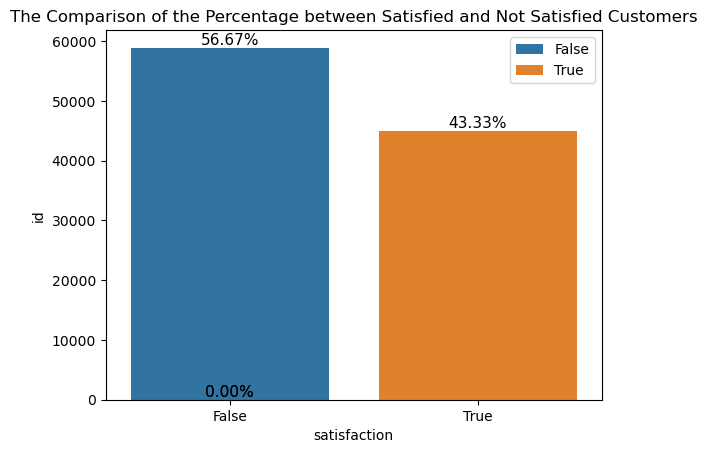

In [27]:
df_satis = df.groupby("satisfaction")["id"].count().reset_index()
ax = sns.barplot(
    data=df_satis, x="satisfaction", y="id", orient="v", hue="satisfaction"
)

total = df_satis["id"].sum()
for p in ax.patches:
    percentage = f"{100 * p.get_height() / total:.2f}%"
    ax.annotate(
        percentage,
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center", va="bottom", fontsize=11
    )

plt.legend(bbox_to_anchor=(1, 1))
plt.title("The Comparison of the Percentage between Satisfied and Not Satisfied Customers")
plt.show()

> Insight

56.67% of passengers are neutral or dissatisfied, while only 43.33% are satisfied. This shows that the majority of passengers are not satisfied with the airline's service.

## 2. What is the percentage of Dissatisfied based on customer characteristics (Gender, loyalty status, Age, Type of Travel, Class, and Flight Distance)?

### a. Gender

#### 1) Statistic Desriptive

In [28]:
F_Gen = df[df['Gender'] == 'Female']
M_Gen = df[df['Gender'] == 'Male']
F_pres = len(F_Gen) / len(df) * 100
M_pres = len(M_Gen) / len(df) * 100
print(f'Number of female customers: {len(F_Gen)}')
print(f'Number of male customers: {len(M_Gen)}')
print(f'Percentage of female customers: {F_pres:.2f}%')
print(f'Percentage of male customers: {M_pres:.2f}%')

Number of female customers: 52727
Number of male customers: 51177
Percentage of female customers: 50.75%
Percentage of male customers: 49.25%


In [29]:
F_NotSatis = F_Gen[F_Gen['satisfaction'] == 0]
M_NotSatis = M_Gen[M_Gen['satisfaction'] == 0]
F_Satis = F_Gen[F_Gen['satisfaction'] == 1]
M_Satis = M_Gen[M_Gen['satisfaction'] == 1]
FCN_Pres = len(F_NotSatis) / len(F_Gen) * 100
MCN_Pres = len(M_NotSatis) / len(M_Gen) * 100
print(f'Number of female customers who are not satisfied = {len(F_NotSatis)}')
print(f'Number of male customers who are not satisfied = {len(M_NotSatis)}')
print(f'Number of female customers who are satisfied = {len(F_Satis)}')
print(f'Number of male customers who are satisfied = {len(M_Satis)}')
print(f'Percentage of female customers who are not satisfied = {FCN_Pres:.2f}%')
print(f'Percentage of male customers who are not satisfied = {MCN_Pres:.2f}%')

Number of female customers who are not satisfied = 30193
Number of male customers who are not satisfied = 28686
Number of female customers who are satisfied = 22534
Number of male customers who are satisfied = 22491
Percentage of female customers who are not satisfied = 57.26%
Percentage of male customers who are not satisfied = 56.05%


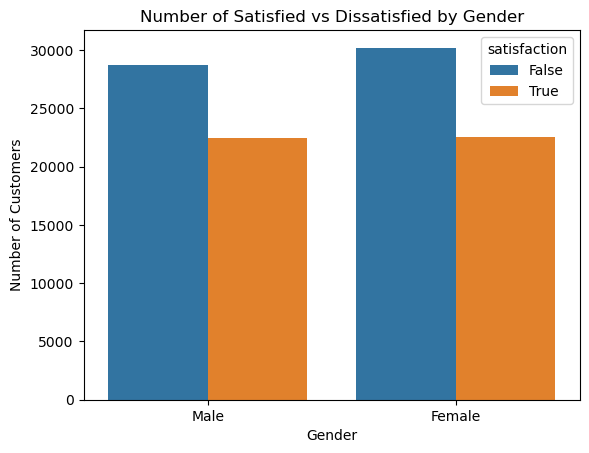

In [30]:
sns.countplot(
    data=df,
    x='Gender',
    hue='satisfaction'
)

plt.title('Number of Satisfied vs Dissatisfied by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.show()

> Insight

The difference between male and female that not satisfied is not significant, with only 1.21% gap.

#### 2) Statistic Inferential

In [31]:
contingency_table = pd.crosstab(df['Gender'], df['satisfaction'])
contingency_table

satisfaction,False,True
Gender,,
Female,30193,22534
Male,28686,22491


In [32]:
res = stats.chi2_contingency(contingency_table)
print("P-value:",res.pvalue)

P-value: 8.496755458033522e-05


In [33]:
# Cramer's V - measure of relationship strength
import scipy.stats as stats
import numpy as np

chi2 = res.statistic
n = contingency_table.sum().sum()
k = min(contingency_table.shape) - 1

cramers_v = np.sqrt(chi2 / (n * k))
print("Cramer's V:", cramers_v)

Cramer's V: 0.012191850597584968


> Insight

The p-value result is 0.0000849 (< 0.05), which means there is a statistically 
significant relationship between gender and satisfaction. However, the Cramer's V 
value is 0.012, which is below 0.1, indicating a very weak relarionship, meaning 
the actual difference between male and female customers is very small, 
with only a 1.21% gap.

### b. Loyalty status

#### 1) Statistic Desriptive

In [34]:
df['Loyalty Status'].value_counts()

Loyalty Status
True     84923
False    18981
Name: count, dtype: Int64

In [35]:
df['Loyalty Status'].unique()

<BooleanArray>
[True, False]
Length: 2, dtype: boolean

In [36]:
LS_Loyal = df[df['Loyalty Status'] == 1]
LS_Disloyal = df[df['Loyalty Status'] == 0]
LSL_pres = len(LS_Loyal) / len(df) * 100
LSD_pres = len(LS_Disloyal) / len(df) * 100
print(f'Number of loyal customers: {len(LS_Loyal)}')
print(f'Number of disloyal customers: {len(LS_Disloyal)}')
print(f'Percentage of loyal customers: {LSL_pres:.2f}%')
print(f'Percentage of disloyal customers: {LSD_pres:.2f}%')

Number of loyal customers: 84923
Number of disloyal customers: 18981
Percentage of loyal customers: 81.73%
Percentage of disloyal customers: 18.27%


In [37]:
LSL_NotSatis = LS_Loyal[LS_Loyal['satisfaction'] == 0]
LSD_NotSatis = LS_Disloyal[LS_Disloyal['satisfaction'] == 0]
LSLN_Pres = len(LSL_NotSatis) / len(LS_Loyal) * 100
LSDN_Pres = len(LSD_NotSatis) / len(LS_Disloyal) * 100
print(f'Number of loyal customers who are not satisfied = {len(LSL_NotSatis)}')
print(f'Number of disloyal customers who are not satisfied = {len(LSD_NotSatis)}')
print(f'Percentage of loyal customers who are not satisfied = {LSLN_Pres:.2f}%')
print(f'Percentage of disloyal customers who are not satisfied = {LSDN_Pres:.2f}%')

Number of loyal customers who are not satisfied = 44390
Number of disloyal customers who are not satisfied = 14489
Percentage of loyal customers who are not satisfied = 52.27%
Percentage of disloyal customers who are not satisfied = 76.33%


In [38]:
contingency_table = pd.crosstab(df['Loyalty Status'], df['satisfaction'])
contingency_table

satisfaction,False,True
Loyalty Status,,
False,14489,4492
True,44390,40533


In [39]:
# Persentase per baris (loyal & disloyal)
contingency_pct = contingency_table.div(contingency_table.sum(axis=1), axis=0) * 100
contingency_pct.columns = ['Not Satisfied (%)', 'Satisfied (%)']
print(contingency_pct.round(2))
print(f'Percentage of disloyal customers who are not satisfied = {contingency_pct.loc[False, "Not Satisfied (%)"]:.2f}%')
print(f'Percentage of loyal customers who are not satisfied = {contingency_pct.loc[True, "Not Satisfied (%)"]:.2f}%')

                Not Satisfied (%)  Satisfied (%)
Loyalty Status                                  
False                       76.33          23.67
True                        52.27          47.73
Percentage of disloyal customers who are not satisfied = 76.33%
Percentage of loyal customers who are not satisfied = 52.27%


C:\Users\User\AppData\Local\Temp\ipykernel_21068\2594225475.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


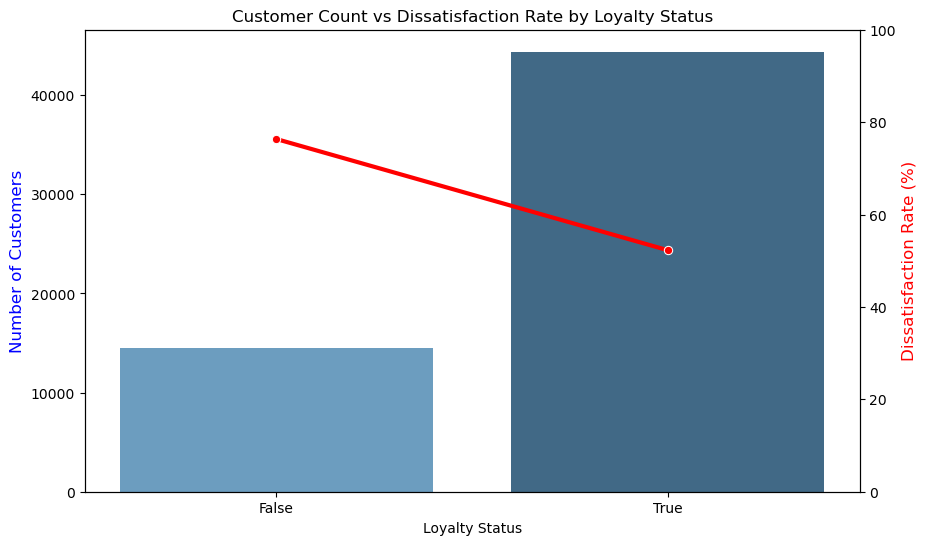

In [40]:
# 1. Setup data
data = df

aggregated_data = df.groupby('Loyalty Status').agg(
    dissatisfied_count=('satisfaction', lambda x: (x == 0).sum()),
    dissatisfaction_rate=('satisfaction', lambda x: (x == 0).mean() * 100)
).reset_index()
# 2. Create first plot (Bar Chart)
fig, ax1 = plt.subplots(figsize=(10, 6))

sns.barplot(
    x=aggregated_data['Loyalty Status'],
    y=aggregated_data['dissatisfied_count'],
    ax=ax1,
    palette='Blues_d'
)

ax1.set_ylabel('Number of Customers', color='blue', fontsize=12)

# 3. Create second Y-axis
ax2 = ax1.twinx()

# 4. Create second plot (Line Chart)
sns.lineplot(
    x=aggregated_data['Loyalty Status'],
    y=aggregated_data['dissatisfaction_rate'],
    marker='o',
    color='red',
    linewidth=3,
    ax=ax2
)

ax2.set_ylabel('Dissatisfaction Rate (%)', color='red', fontsize=12)

# Biar persen 0–100
ax2.set_ylim(0, 100)

plt.title('Customer Count vs Dissatisfaction Rate by Loyalty Status')
plt.xlabel('Loyalty Status')

plt.show()

> Insight

It shows disloyal customer more disatisfied than loyal customer that disatisfied, around 76.33%.

#### 2) Statistic Inferential

In [41]:
contingency_table

satisfaction,False,True
Loyalty Status,,
False,14489,4492
True,44390,40533


In [42]:
res = stats.chi2_contingency(contingency_table)
print('P-value:', res.pvalue)

P-value: 0.0


In [43]:
chi2 = res.statistic
n = contingency_table.sum().sum()
k = min(contingency_table.shape) - 1

cramers_v = np.sqrt(chi2 / (n * k))
print("Cramer's V:", cramers_v)

Cramer's V: 0.18761303964984952


> Insight

P-value ≈ 0 (p < 0.05), meaning loyalty status and satisfaction are related. 
The Cramer's V value of 0.187, which is above 0.1 and below 0.3, indicates 
a weak to moderate relationship. This is also reflected in the dissatisfaction 
rate gap of only 24.06% between disloyal customers (76.33%) and loyal 
customers (52.27%).

### c. Age

#### 1) Statistic Desriptive

In [44]:
df['Age'].describe()

count    103904.000000
mean         39.379706
std          15.114964
min           7.000000
25%          27.000000
50%          40.000000
75%          51.000000
max          85.000000
Name: Age, dtype: float64

<Axes: >

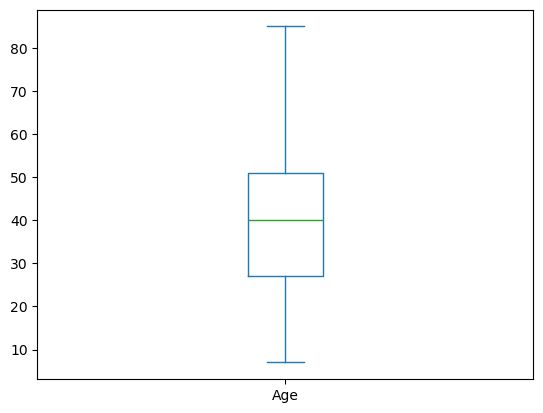

In [45]:
df['Age'].plot.box()

In [46]:
A_Satis_Yes = df[df['satisfaction'] == 1]['Age']
A_Satis_No = df[df['satisfaction'] == 0]['Age']

In [47]:
A_Satis_Yes.describe()

count    45025.000000
mean        41.750583
std         12.767833
min          7.000000
25%         32.000000
50%         43.000000
75%         51.000000
max         85.000000
Name: Age, dtype: float64

In [48]:
A_Satis_No.describe()

count    58879.000000
mean        37.566688
std         16.459825
min          7.000000
25%         25.000000
50%         36.000000
75%         50.000000
max         85.000000
Name: Age, dtype: float64

<Axes: ylabel='Frequency'>

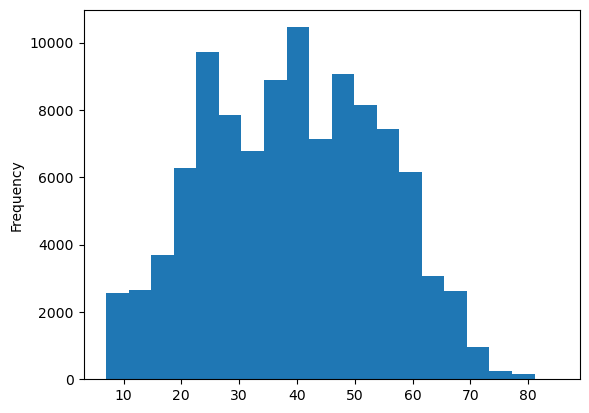

In [49]:
df['Age'].plot(kind='hist', bins=20)

In [50]:
import scipy.stats as stats
stat, p_value = stats.normaltest(df['Age'])

print(f"Statistic: {stat}")
print(f"P-value: {p_value}")

if p_value > 0.05:
    print("Data normal")
else:
    print("Data not normal")

Statistic: 6031.722490669641
P-value: 0.0
Data not normal


Normality Test shows the data is not normal

In [51]:
df['Age'].kurtosis()

np.float64(-0.719568116947273)

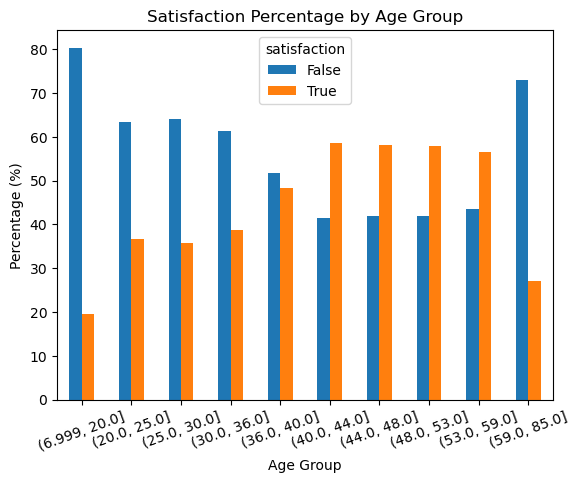

In [52]:
df['AS_group'] = pd.qcut(df['Age'], q=10)
Age_Satis_pct = pd.crosstab( df['AS_group'], df['satisfaction'], normalize='index' ) * 100
Age_Satis_pct.plot(kind='bar')

plt.title('Satisfaction Percentage by Age Group')
plt.ylabel('Percentage (%)')
plt.xlabel('Age Group')
plt.xticks(rotation=20)
plt.show()

In [53]:
result = (1 - df.groupby('AS_group')['satisfaction'].mean()) * 100
result

C:\Users\User\AppData\Local\Temp\ipykernel_21068\2999861224.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = (1 - df.groupby('AS_group')['satisfaction'].mean()) * 100


AS_group
(6.999, 20.0]    80.375893
(20.0, 25.0]     63.421986
(25.0, 30.0]     64.175868
(30.0, 36.0]     61.280958
(36.0, 40.0]     51.709234
(40.0, 44.0]     41.513903
(44.0, 48.0]     41.933377
(48.0, 53.0]     41.999229
(53.0, 59.0]     43.486992
(59.0, 85.0]     72.877868
Name: satisfaction, dtype: Float64

Percentage of customers who have Age from 7 - 20 = 80.37%

Percentage of customers who have Age from 20 - 25 = 63.42%

Percentage of customers who have Age from 25 - 30 = 64.17%

Percentage of customers who have Age from 30 - 36 = 61.28%

Percentage of customers who have Age from 36 - 40 = 51.71%

Percentage of customers who have Age from 40 - 44 = 41.51%

Percentage of customers who have Age from 44 - 48 = 41.93%

Percentage of customers who have Age from 48 - 53 = 42%

Percentage of customers who have Age from 53 - 59 = 43.48%

Percentage of customers who have Age from 59 - 85 = 72.87%

> Insight

Top 3 not satisfied percentage of Age is from 7 - 20 (80.37%), from 59 - 85 (72.87%), and from 25 - 30 (64.17%).

#### 2) Statistic Inferential

In [54]:
from scipy.stats import mannwhitneyu

mannwhitneyu(A_Satis_Yes, A_Satis_No)

MannwhitneyuResult(statistic=np.float64(1552716162.5), pvalue=np.float64(0.0))

In [55]:
# Effect size untuk Mann-Whitney = r
import numpy as np
n = len(A_Satis_Yes) + len(A_Satis_No)
r = 1 - (2 * mannwhitneyu(A_Satis_Yes, A_Satis_No).statistic) / (len(A_Satis_Yes) * len(A_Satis_No))
print(f'Effect size (r): {r:.4f}')

Effect size (r): -0.1714


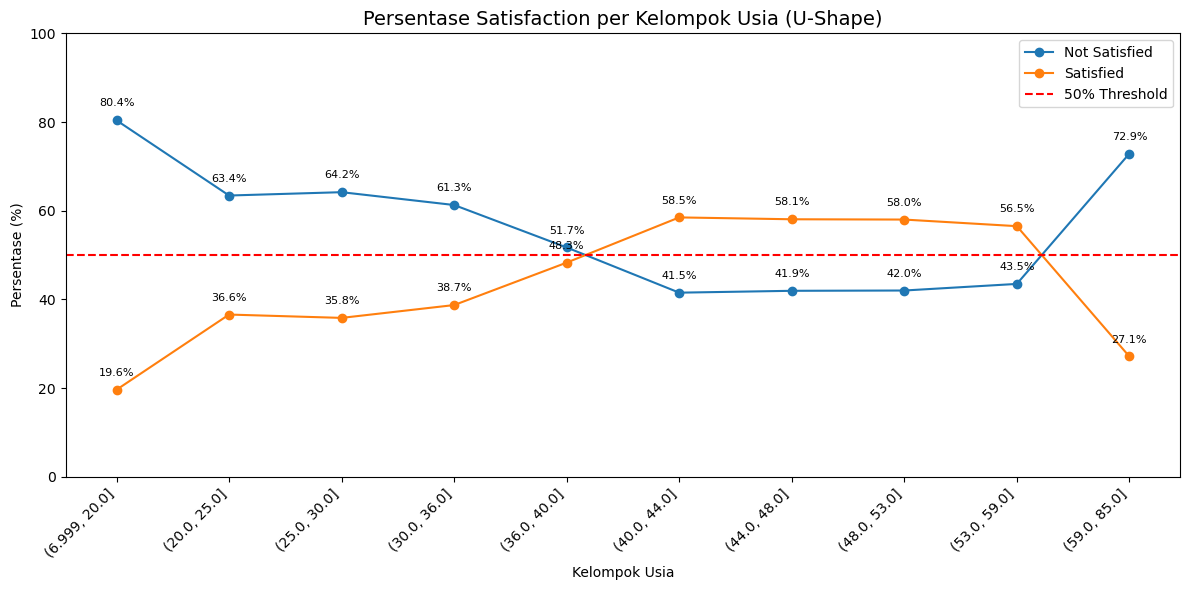

In [56]:
df['AS_group'] = pd.qcut(df['Age'], q=10)
Age_Satis_pct = pd.crosstab(df['AS_group'], df['satisfaction'], normalize='index') * 100

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
Age_Satis_pct.plot(kind='line', marker='o', ax=ax)

# Garis 50%
ax.axhline(y=50, color='red', linestyle='--', label='50% threshold')

# Anotasi nilai
for col in Age_Satis_pct.columns:
    for i, val in enumerate(Age_Satis_pct[col]):
        ax.annotate(f'{val:.1f}%', 
                    (i, val), 
                    textcoords="offset points", 
                    xytext=(0, 10), 
                    ha='center', 
                    fontsize=8)

ax.set_title('Persentase Satisfaction per Kelompok Usia (U-Shape)', fontsize=14)
ax.set_xlabel('Kelompok Usia')
ax.set_ylabel('Persentase (%)')

# Ganti ini
ax.set_xticks(range(len(Age_Satis_pct.index)))
ax.set_xticklabels([str(x) for x in Age_Satis_pct.index], rotation=45, ha='right')

ax.legend(['Not Satisfied', 'Satisfied', '50% Threshold'])
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

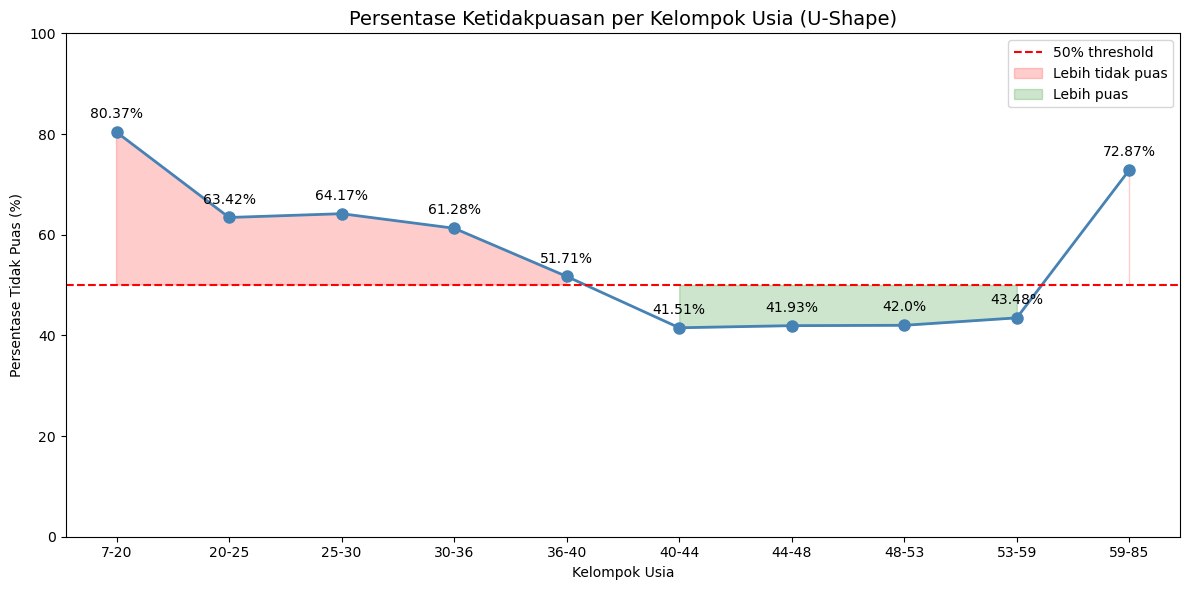

In [57]:
import matplotlib.pyplot as plt
import numpy as np

usia = ['7-20', '20-25', '25-30', '30-36', '36-40', '40-44', '44-48', '48-53', '53-59', '59-85']
pct = [80.37, 63.42, 64.17, 61.28, 51.71, 41.51, 41.93, 42.00, 43.48, 72.87]

plt.figure(figsize=(12, 6))
plt.plot(usia, pct, marker='o', color='steelblue', linewidth=2, markersize=8)
plt.axhline(y=50, color='red', linestyle='--', label='50% threshold')
plt.fill_between(range(len(usia)), pct, 50, 
                 where=[p > 50 for p in pct], 
                 alpha=0.2, color='red', label='Lebih tidak puas')
plt.fill_between(range(len(usia)), pct, 50, 
                 where=[p <= 50 for p in pct], 
                 alpha=0.2, color='green', label='Lebih puas')

for i, (x, y) in enumerate(zip(usia, pct)):
    plt.annotate(f'{y}%', (x, y), textcoords="offset points", xytext=(0, 10), ha='center')

plt.title('Persentase Ketidakpuasan per Kelompok Usia (U-Shape)', fontsize=14)
plt.xlabel('Kelompok Usia')
plt.ylabel('Persentase Tidak Puas (%)')
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

> Insight

The Mann-Whitney U test shows a p-value ≈ 0 (p < 0.05), meaning there is 
a significant difference in age distribution between satisfied and dissatisfied 
customers. However, the effect size r = -0.1714, which is between 0.1 and 0.3, 
indicates a weak relationship. The negative sign shows that younger customers 
tend to be more dissatisfied, with the highest dissatisfaction rate in the 
7-20 age group (80.37%) and the lowest in the 40-44 age group (41.51%).

### d. Type of Travel

#### 1) Statistic Desriptive

In [58]:
df['Type of Travel'].unique()

array(['Personal Travel', 'Business travel'], dtype=object)

In [59]:
TT_PT = df[df['Type of Travel'] == 'Personal Travel']
TT_BT = df[df['Type of Travel'] == 'Business travel']
TT_PT_Pres = len(TT_PT) / len(df) * 100
TT_BT_Pres = len(TT_BT) / len(df) * 100
print(f'Number of customers who travel for personal reasons: {len(TT_PT)}')
print(f'Number of customers who travel for business reasons: {len(TT_BT)}')
print(f'Percentage of customers who travel for personal reasons: {TT_PT_Pres:.2f}%')
print(f'Percentage of customers who travel for business reasons: {TT_BT_Pres:.2f}%')

Number of customers who travel for personal reasons: 32249
Number of customers who travel for business reasons: 71655
Percentage of customers who travel for personal reasons: 31.04%
Percentage of customers who travel for business reasons: 68.96%


In [60]:
contingency_table = pd.crosstab(df['Type of Travel'], df['satisfaction'])

In [61]:
contingency_pct = contingency_table.div(contingency_table.sum(axis=1), axis=0) * 100
contingency_pct.columns = ['Not Satisfied (%)', 'Satisfied (%)']
print(contingency_pct.round(2))
print(f'Percentage of Business Travel who are not satisfied = {contingency_pct.loc["Business travel", "Not Satisfied (%)"]:.2f}%')
print(f'Percentage of Personal Travel who are not satisfied = {contingency_pct.loc["Personal Travel", "Not Satisfied (%)"]:.2f}%')

                 Not Satisfied (%)  Satisfied (%)
Type of Travel                                   
Business travel              41.74          58.26
Personal Travel              89.83          10.17
Percentage of Business Travel who are not satisfied = 41.74%
Percentage of Personal Travel who are not satisfied = 89.83%


C:\Users\User\AppData\Local\Temp\ipykernel_21068\2155105680.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


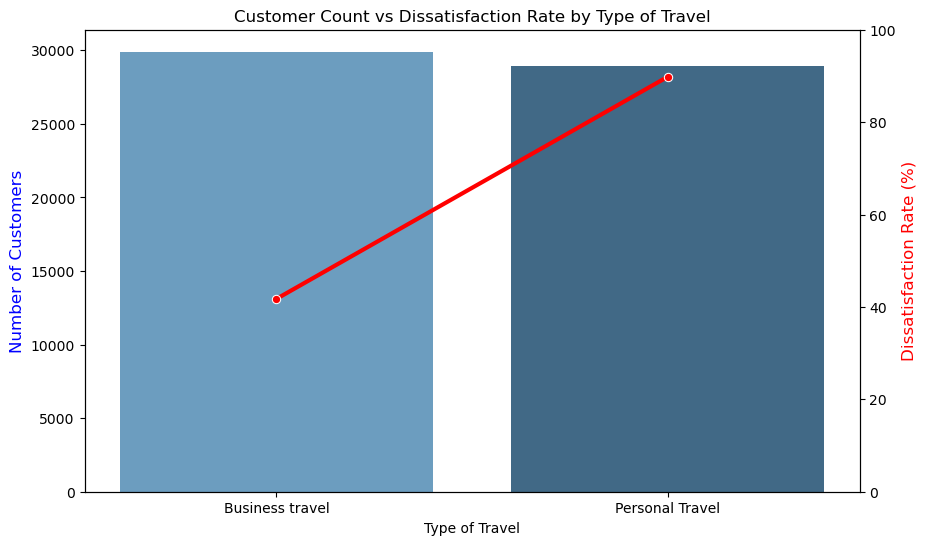

In [62]:
# 1. Setup data
data = df

aggregated_data = df.groupby('Type of Travel').agg(
    dissatisfied_count=('satisfaction', lambda x: (x == 0).sum()),
    dissatisfaction_rate=('satisfaction', lambda x: (x == 0).mean() * 100)
).reset_index()
# 2. Create first plot (Bar Chart)
fig, ax1 = plt.subplots(figsize=(10, 6))

sns.barplot(
    x=aggregated_data['Type of Travel'],
    y=aggregated_data['dissatisfied_count'],
    ax=ax1,
    palette='Blues_d'
)

ax1.set_ylabel('Number of Customers', color='blue', fontsize=12)

# 3. Create second Y-axis
ax2 = ax1.twinx()

# 4. Create second plot (Line Chart)
sns.lineplot(
    x=aggregated_data['Type of Travel'],
    y=aggregated_data['dissatisfaction_rate'],
    marker='o',
    color='red',
    linewidth=3,
    ax=ax2
)

ax2.set_ylabel('Dissatisfaction Rate (%)', color='red', fontsize=12)

# Biar persen 0–100
ax2.set_ylim(0, 100)

plt.title('Customer Count vs Dissatisfaction Rate by Type of Travel')
plt.xlabel('Type of Travel')

plt.show()

> Insight

It shows the higher dissatisfaction rate is personal travel, around 89.83%

#### 2) Statistic Inferential

In [63]:
contingency_table = pd.crosstab(df['Type of Travel'], df['satisfaction'])
contingency_table

satisfaction,False,True
Type of Travel,,
Business travel,29909,41746
Personal Travel,28970,3279


In [64]:
res = stats.chi2_contingency(contingency_table)
print("P-value:",res.pvalue)

P-value: 0.0


In [65]:
# Cramer's V - measure of relationship strength
import scipy.stats as stats
import numpy as np

chi2 = res.statistic
n = contingency_table.sum().sum()
k = min(contingency_table.shape) - 1

cramers_v = np.sqrt(chi2 / (n * k))
print("Cramer's V:", cramers_v)

Cramer's V: 0.44897945977699316


In [66]:
contingency_pct = contingency_table.div(contingency_table.sum(axis=1), axis=0) * 100
contingency_pct.columns = ['Not Satisfied (%)', 'Satisfied (%)']
print(contingency_pct.round(2))
print(f'Percentage of Business Travel who are not satisfied = {contingency_pct.loc["Business travel", "Not Satisfied (%)"]:.2f}%')
print(f'Percentage of Personal Travel who are not satisfied = {contingency_pct.loc["Personal Travel", "Not Satisfied (%)"]:.2f}%')

                 Not Satisfied (%)  Satisfied (%)
Type of Travel                                   
Business travel              41.74          58.26
Personal Travel              89.83          10.17
Percentage of Business Travel who are not satisfied = 41.74%
Percentage of Personal Travel who are not satisfied = 89.83%


> Insight

P-value ≈ 0 (p < 0.05), meaning Type of Travel and satisfaction are related. 
The Cramer's V value of 0.448, which is above 0.3, indicates a strong 
relationship. This is also reflected in the dissatisfaction rate gap of 
48.09% between Personal Travel customers (89.83%) and Business Travel 
customers (41.74%).

### e. Class

#### 1) Statistic Desriptive

In [67]:
df['Class'].unique()

array(['Eco Plus', 'Business', 'Eco'], dtype=object)

In [68]:
Class_EcoPlus = df[df['Class'] == 'Eco Plus']
Class_Eco = df[df['Class'] == 'Eco']
Class_Bus = df[df['Class'] == 'Business']
Class_EcoPlus_Pres = len(Class_EcoPlus) / len(df) * 100
Class_Eco_Pres = len(Class_Eco) / len(df) * 100
Class_Bus_Pres = len(Class_Bus) / len(df) * 100
print(f'Number of customers in Eco Plus class: {len(Class_EcoPlus)}')
print(f'Number of customers in Eco class: {len(Class_Eco)}')  
print(f'Number of customers in Business class: {len(Class_Bus)}')
print(f'Percentage of customers in Eco Plus class: {Class_EcoPlus_Pres:.2f}%')
print(f'Percentage of customers in Eco class: {Class_Eco_Pres:.2f}%')
print(f'Percentage of customers in Business class: {Class_Bus_Pres:.2f}%')

Number of customers in Eco Plus class: 7494
Number of customers in Eco class: 46745
Number of customers in Business class: 49665
Percentage of customers in Eco Plus class: 7.21%
Percentage of customers in Eco class: 44.99%
Percentage of customers in Business class: 47.80%


In [69]:
CEP_NotSatis = Class_EcoPlus[Class_EcoPlus['satisfaction'] == 0]
CE_NotSatis = Class_Eco[Class_Eco['satisfaction'] == 0]
CB_NotSatis = Class_Bus[Class_Bus['satisfaction'] == 0]
CEP_NotSatis_Pres = len(CEP_NotSatis) / len(Class_EcoPlus) * 100
CE_NotSatis_Pres = len(CE_NotSatis) / len(Class_Eco) * 100
CB_NotSatis_Pres = len(CB_NotSatis) / len(Class_Bus) * 100
print(f'Number of customers in Eco Plus class who are not satisfied: {len(CEP_NotSatis)}')
print(f'Number of customers in Eco class who are not satisfied: {len(CE_NotSatis)}')
print(f'Number of customers in Business class who are not satisfied: {len(CB_NotSatis)}')
print(f'Percentage of customers in Eco Plus class who are not satisfied: {CEP_NotSatis_Pres:.2f}%')
print(f'Percentage of customers in Eco class who are not satisfied: {CE_NotSatis_Pres:.2f}%')
print(f'Percentage of customers in Business class who are not satisfied: {CB_NotSatis_Pres:.2f}%')

Number of customers in Eco Plus class who are not satisfied: 5650
Number of customers in Eco class who are not satisfied: 38044
Number of customers in Business class who are not satisfied: 15185
Percentage of customers in Eco Plus class who are not satisfied: 75.39%
Percentage of customers in Eco class who are not satisfied: 81.39%
Percentage of customers in Business class who are not satisfied: 30.57%


C:\Users\User\AppData\Local\Temp\ipykernel_21068\2227297232.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


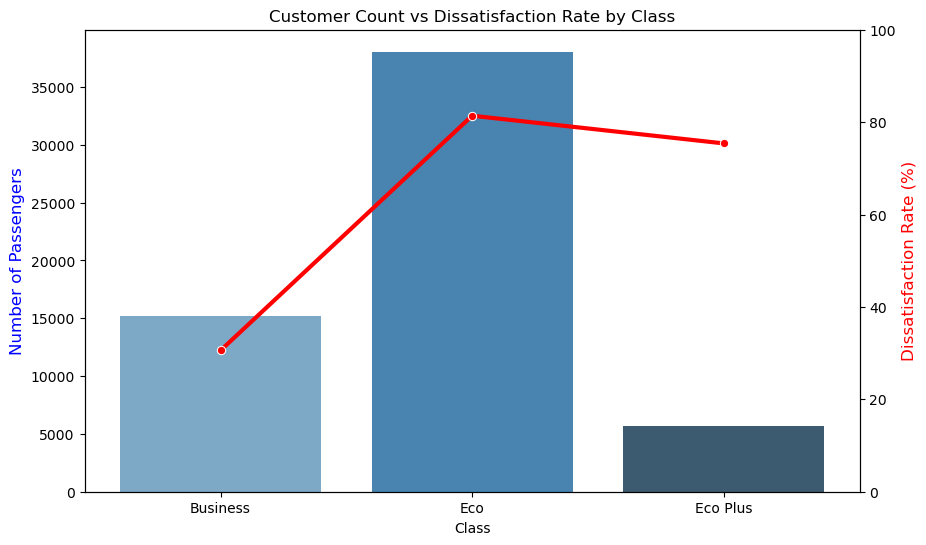

In [70]:
# 1. Setup data
data = df

aggregated_data = df.groupby('Class').agg(
    dissatisfied_count=('satisfaction', lambda x: (x == 0).sum()),
    dissatisfaction_rate=('satisfaction', lambda x: (x == 0).mean() * 100)
).reset_index()

# 2. Create first plot (Bar Chart)
fig, ax1 = plt.subplots(figsize=(10, 6))

sns.barplot(
    x=aggregated_data['Class'],
    y=aggregated_data['dissatisfied_count'],
    ax=ax1,
    palette='Blues_d'
)

ax1.set_ylabel('Number of Passengers', color='blue', fontsize=12)

# 3. Create second Y-axis
ax2 = ax1.twinx()

# 4. Create second plot (Line Chart)
sns.lineplot(
    x=aggregated_data['Class'],
    y=aggregated_data['dissatisfaction_rate'],
    marker='o',
    color='red',
    linewidth=3,
    ax=ax2
)

ax2.set_ylabel('Dissatisfaction Rate (%)', color='red', fontsize=12)

# Biar persen 0–100
ax2.set_ylim(0, 100)

plt.title('Customer Count vs Dissatisfaction Rate by Class')
plt.xlabel('Class')

plt.show()

> Insight

It shows the higher dissatisfaction rate is Eco Class, around 81.39%, and follows by Eco Plus with 75.39%

#### 2) Statistic Inferential

In [71]:
contingency_table = pd.crosstab(df['Class'], df['satisfaction'])
contingency_table

satisfaction,False,True
Class,,
Business,15185,34480
Eco,38044,8701
Eco Plus,5650,1844


In [72]:
res = stats.chi2_contingency(contingency_table)
print("P-value:",res.pvalue)

P-value: 0.0


In [73]:
# Cramer's V - measure of relationship strength
chi2 = res.statistic
n = contingency_table.sum().sum()
k = min(contingency_table.shape) - 1

cramers_v = np.sqrt(chi2 / (n * k))
print("Cramer's V:", cramers_v)

Cramer's V: 0.5047497579440323


In [74]:
contingency_pct = contingency_table.div(contingency_table.sum(axis=1), axis=0) * 100
contingency_pct.columns = ['Not Satisfied (%)', 'Satisfied (%)']
print(contingency_pct.round(2))
print(f'Percentage of Business class who are not satisfied = {contingency_pct.loc["Business", "Not Satisfied (%)"]:.2f}%')
print(f'Percentage of Eco class who are not satisfied = {contingency_pct.loc["Eco", "Not Satisfied (%)"]:.2f}%')
print(f'Percentage of Eco Plus class who are not satisfied = {contingency_pct.loc["Eco Plus", "Not Satisfied (%)"]:.2f}%')

          Not Satisfied (%)  Satisfied (%)
Class                                     
Business              30.57          69.43
Eco                   81.39          18.61
Eco Plus              75.39          24.61
Percentage of Business class who are not satisfied = 30.57%
Percentage of Eco class who are not satisfied = 81.39%
Percentage of Eco Plus class who are not satisfied = 75.39%


In [75]:
from itertools import combinations
import scipy.stats as stats

classes = ['Business', 'Eco', 'Eco Plus']

for class1, class2 in combinations(classes, 2):
    table = contingency_table.loc[[class1, class2]]
    chi2, p, _, _ = stats.chi2_contingency(table)
    print(f'{class1} vs {class2}: p-value = {p:.4f}')

Business vs Eco: p-value = 0.0000
Business vs Eco Plus: p-value = 0.0000
Eco vs Eco Plus: p-value = 0.0000


In [76]:
for class1, class2 in combinations(classes, 2):
    table = contingency_table.loc[[class1, class2]]
    chi2, p, _, _ = stats.chi2_contingency(table)
    n = table.sum().sum()
    k = min(table.shape) - 1
    v = np.sqrt(chi2 / (n * k))
    print(f'{class1} vs {class2}: p-value = {p:.4f}, Cramers V = {v:.4f}')

Business vs Eco: p-value = 0.0000, Cramers V = 0.5106
Business vs Eco Plus: p-value = 0.0000, Cramers V = 0.3142
Eco vs Eco Plus: p-value = 0.0000, Cramers V = 0.0522


> Insight

P-value ≈ 0 (p < 0.05), meaning Class and satisfaction are related. 
The Cramer's V value of 0.504, which is above 0.3, indicates a strong 
relationship. This is reflected in the dissatisfaction rate gap of 50.82% 
between Eco class (81.39%) and Business class (30.57%). Post-hoc analysis 
shows the largest difference between Business and Eco (Cramer's V = 0.5106), 
while Eco and Eco Plus are relatively similar (Cramer's V = 0.0522).

### f. Flight Distance

#### 1) Statistic Desriptive

In [77]:
df.columns

Index(['id', 'Gender', 'Loyalty Status', 'Age', 'Type of Travel', 'Class',
       'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction', 'AS_group'],
      dtype='object')

In [78]:
df['Flight Distance'].describe()

count    103904.000000
mean       1189.448375
std         997.147281
min          31.000000
25%         414.000000
50%         843.000000
75%        1743.000000
max        4983.000000
Name: Flight Distance, dtype: float64

<Axes: >

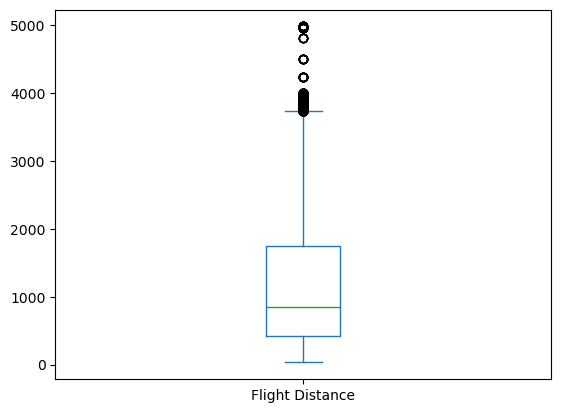

In [79]:
df['Flight Distance'].plot.box()

The boxplot shows any outliers in distance 4000 km until 5000 km

<Axes: xlabel='Flight Distance', ylabel='Count'>

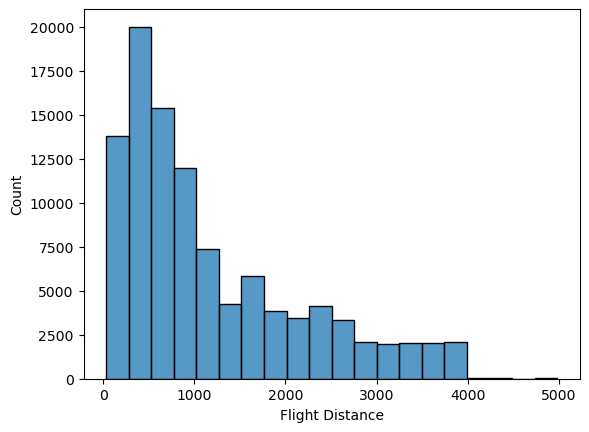

In [80]:
sns.histplot(x=df['Flight Distance'], bins=20)

In [81]:
FD_Satis = df[df['satisfaction'] == 1]['Flight Distance']
FD_Satis.describe()

count    45025.000000
mean      1530.140255
std       1128.126574
min         31.000000
25%        526.000000
50%       1250.000000
75%       2405.000000
max       4983.000000
Name: Flight Distance, dtype: float64

In [82]:
FD_NotSatis = df[df['satisfaction'] == 0]['Flight Distance']
FD_NotSatis.describe()

count    58879.000000
mean       928.919971
std        790.452308
min         31.000000
25%        372.000000
50%        671.000000
75%       1158.000000
max       4983.000000
Name: Flight Distance, dtype: float64

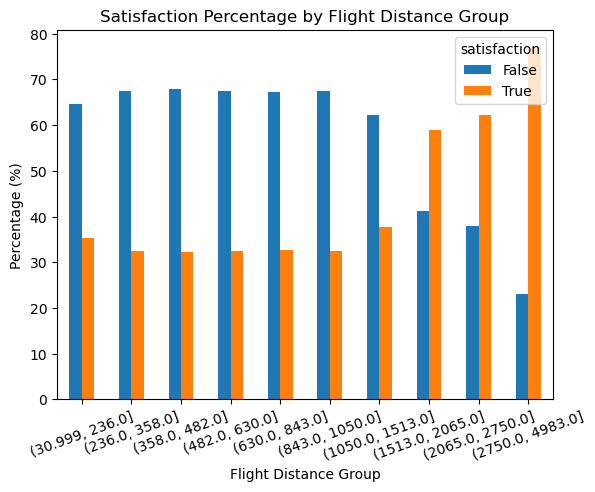

In [83]:
df['FD_group'] = pd.qcut(df['Flight Distance'], q=10)
tenure_churn_pct = pd.crosstab( df['FD_group'], df['satisfaction'], normalize='index' ) * 100
tenure_churn_pct.plot(kind='bar')

plt.title('Satisfaction Percentage by Flight Distance Group')
plt.ylabel('Percentage (%)')
plt.xlabel('Flight Distance Group')
plt.xticks(rotation=20)
plt.show()

In [84]:
result = (1 - df.groupby('FD_group')['satisfaction'].mean()) * 100
result

C:\Users\User\AppData\Local\Temp\ipykernel_21068\1286806168.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = (1 - df.groupby('FD_group')['satisfaction'].mean()) * 100


FD_group
(30.999, 236.0]     64.714272
(236.0, 358.0]       67.44141
(358.0, 482.0]      67.815759
(482.0, 630.0]      67.492557
(630.0, 843.0]      67.280973
(843.0, 1050.0]     67.553902
(1050.0, 1513.0]    62.310237
(1513.0, 2065.0]    41.149889
(2065.0, 2750.0]     37.87689
(2750.0, 4983.0]     22.99769
Name: satisfaction, dtype: Float64

Percentage of customers who are not satisfied by Flight Distance range:

31 km - 236 km: 64.71%

236 km - 358 km: 67.44%

358 km - 482 km: 67.82%

482 km - 630 km: 67.49%

630 km - 843 km: 67.28%

843 km - 1050 km: 67.55%

1050 km - 1513 km: 62.31%

1513 km - 2065 km: 41.15%

2065 km - 2750 km: 37.88%

2750 km - 4983 km: 22.99%

Top 3 dissatisfied percentage of Flight Distance is from 358 km - 482 km (67.82%), 843 km - 1050 km (67.55%), and 482 km - 630 km (67.49%).

> Insight

The three highest dissatisfaction rates are Personal Travel (89.83%), Eco Class (81.39%), and Age 7–20 (80.37%). This shows that the worst dissatisfaction comes from type of travel and cabin class segments.

In [85]:
import scipy.stats as stats
stat, p_value = stats.normaltest(df['Flight Distance'])

print(f"Statistic: {stat}")
print(f"P-value: {p_value}")

if p_value > 0.05:
    print("Data normal")
else:
    print("Data not normal")

Statistic: 14568.95534710709
P-value: 0.0
Data not normal


#### 2) Statistic Inferential

In [115]:
stat, p = mannwhitneyu(FD_Satis, FD_NotSatis)
r = 1 - (2 * stat) / (len(FD_Satis) * len(FD_NotSatis))

print('Flight Distance:')
print(f'  p-value = {p:.4f}')
print(f'  Effect size r = {r:.4f}')

Flight Distance:
  p-value = 0.0000
  Effect size r = -0.2998


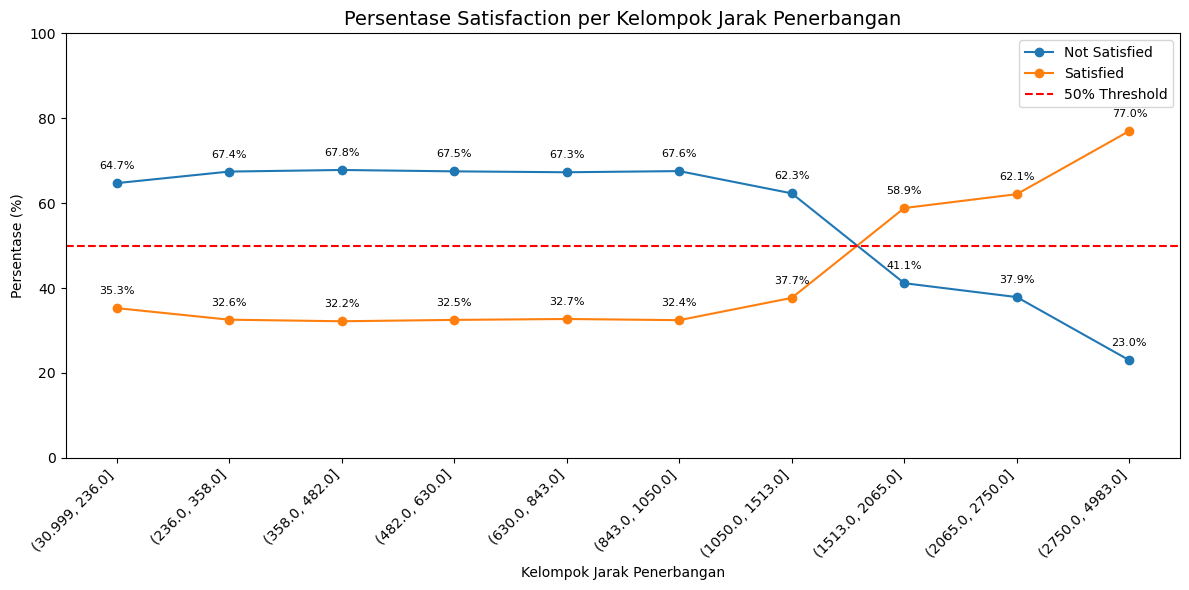

In [88]:
df['FD_group'] = pd.qcut(df['Flight Distance'], q=10)
FD_Satis_pct = pd.crosstab(df['FD_group'], df['satisfaction'], normalize='index') * 100

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
FD_Satis_pct.plot(kind='line', marker='o', ax=ax)

# Garis 50%
ax.axhline(y=50, color='red', linestyle='--', label='50% threshold')

# Anotasi nilai
for col in FD_Satis_pct.columns:
    for i, val in enumerate(FD_Satis_pct[col]):
        ax.annotate(f'{val:.1f}%', 
                    (i, val), 
                    textcoords="offset points", 
                    xytext=(0, 10), 
                    ha='center', 
                    fontsize=8)

ax.set_title('Persentase Satisfaction per Kelompok Jarak Penerbangan', fontsize=14)
ax.set_xlabel('Kelompok Jarak Penerbangan')
ax.set_ylabel('Persentase (%)')

ax.set_xticks(range(len(FD_Satis_pct.index)))
ax.set_xticklabels([str(x) for x in FD_Satis_pct.index], rotation=45, ha='right')

ax.legend(['Not Satisfied', 'Satisfied', '50% Threshold'])
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

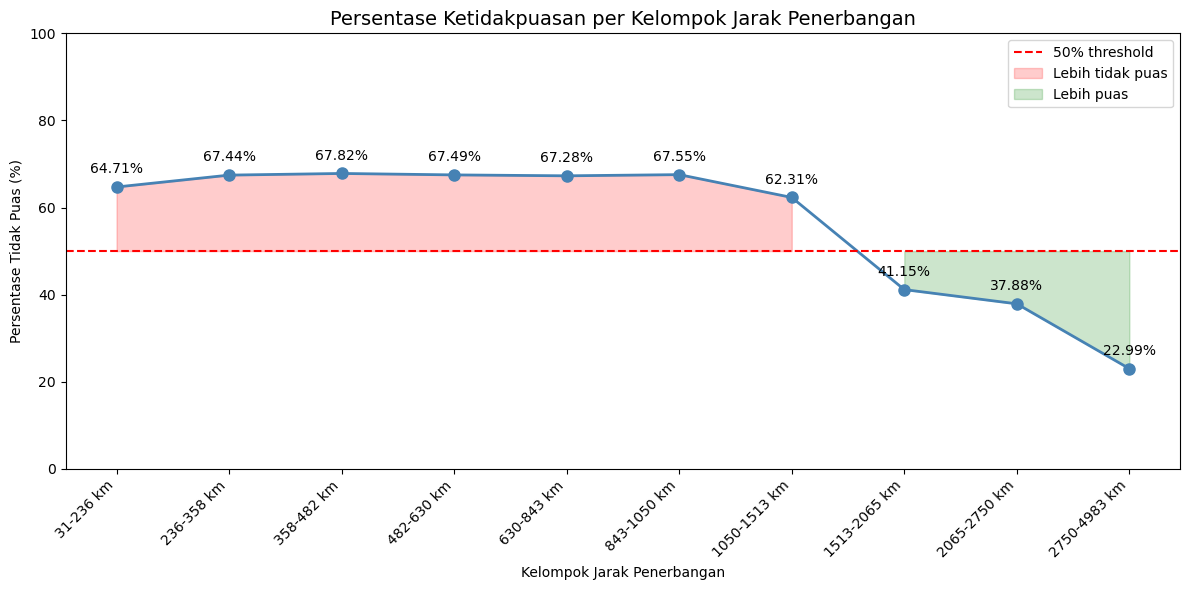

In [89]:
flight_distance = ['31-236 km', '236-358 km', '358-482 km', '482-630 km', '630-843 km', 
                   '843-1050 km', '1050-1513 km', '1513-2065 km', '2065-2750 km', '2750-4983 km']
pct = [64.71, 67.44, 67.82, 67.49, 67.28, 67.55, 62.31, 41.15, 37.88, 22.99]

plt.figure(figsize=(12, 6))
plt.plot(flight_distance, pct, marker='o', color='steelblue', linewidth=2, markersize=8)
plt.axhline(y=50, color='red', linestyle='--', label='50% threshold')
plt.fill_between(range(len(flight_distance)), pct, 50, 
                 where=[p > 50 for p in pct], 
                 alpha=0.2, color='red', label='Lebih tidak puas')
plt.fill_between(range(len(flight_distance)), pct, 50, 
                 where=[p <= 50 for p in pct], 
                 alpha=0.2, color='green', label='Lebih puas')

for i, (x, y) in enumerate(zip(flight_distance, pct)):
    plt.annotate(f'{y}%', (x, y), textcoords="offset points", xytext=(0, 10), ha='center')

plt.title('Persentase Ketidakpuasan per Kelompok Jarak Penerbangan', fontsize=14)
plt.xlabel('Kelompok Jarak Penerbangan')
plt.ylabel('Persentase Tidak Puas (%)')
plt.ylim(0, 100)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

> Insight

The Mann-Whitney U test shows a p-value ≈ 0 (p < 0.05), meaning there is a significant difference in flight distance distribution between satisfied and dissatisfied customers. However, the effect size r = -0.2998, which is between 0.1 and 0.3, indicates a weak relationship. The negative sign shows that customers with shorter flight distances tend to be more dissatisfied, with the highest dissatisfaction rate in the 358-482 km range (67.82%) and the lowest in the 2750-4983 km range (22.99%).

## 3. What is the dissatisfaction rate distribution across in-flight services (Inflight wifi service, Food and drink, Seat comfort, Inflight entertainment, On-board service, Inflight service, and Cleanliness)? Which in-flight service has the highest percentage of dissatisfied passengers?

#### 1) Statistic Desriptive

In [90]:
inflight_cols = [
    'Inflight wifi service', 'Food and drink', 'Seat comfort',
    'Inflight entertainment', 'On-board service', 'Inflight service', 'Cleanliness'
]

for col in inflight_cols:
    print(f'{col}:')
    for rating in range(0, 6):
        count = len(df[df[col] == rating])
        pres = count / len(df) * 100
        print(f'  Rating {rating}: {count} ({pres:.2f}%)')
    print()

Inflight wifi service:
  Rating 0: 3103 (2.99%)
  Rating 1: 17840 (17.17%)
  Rating 2: 25830 (24.86%)
  Rating 3: 25868 (24.90%)
  Rating 4: 19794 (19.05%)
  Rating 5: 11469 (11.04%)

Food and drink:
  Rating 0: 107 (0.10%)
  Rating 1: 12837 (12.35%)
  Rating 2: 21988 (21.16%)
  Rating 3: 22300 (21.46%)
  Rating 4: 24359 (23.44%)
  Rating 5: 22313 (21.47%)

Seat comfort:
  Rating 0: 1 (0.00%)
  Rating 1: 12075 (11.62%)
  Rating 2: 14897 (14.34%)
  Rating 3: 18696 (17.99%)
  Rating 4: 31765 (30.57%)
  Rating 5: 26470 (25.48%)

Inflight entertainment:
  Rating 0: 14 (0.01%)
  Rating 1: 12478 (12.01%)
  Rating 2: 17637 (16.97%)
  Rating 3: 19139 (18.42%)
  Rating 4: 29423 (28.32%)
  Rating 5: 25213 (24.27%)

On-board service:
  Rating 0: 3 (0.00%)
  Rating 1: 11872 (11.43%)
  Rating 2: 14681 (14.13%)
  Rating 3: 22833 (21.98%)
  Rating 4: 30867 (29.71%)
  Rating 5: 23648 (22.76%)

Inflight service:
  Rating 0: 3 (0.00%)
  Rating 1: 7084 (6.82%)
  Rating 2: 11457 (11.03%)
  Rating 3: 20299

In [91]:
not_satisfied = df[df['satisfaction'] == False]
inflight_cols = [
    'Inflight wifi service', 'Food and drink', 'Seat comfort',
    'Inflight entertainment', 'On-board service', 'Inflight service', 'Cleanliness'
]

for col in inflight_cols:
    print(f'{col}:')
    for rating in range(0, 6):
        count = len(not_satisfied[not_satisfied[col] == rating])
        pres = count / len(not_satisfied) * 100
        print(f'  Rating {rating}: {count} ({pres:.2f}%)')
    print()

Inflight wifi service:
  Rating 0: 8 (0.01%)
  Rating 1: 12034 (20.44%)
  Rating 2: 19407 (32.96%)
  Rating 3: 19386 (32.93%)
  Rating 4: 7938 (13.48%)
  Rating 5: 106 (0.18%)

Food and drink:
  Rating 0: 57 (0.10%)
  Rating 1: 10269 (17.44%)
  Rating 2: 13458 (22.86%)
  Rating 3: 13461 (22.86%)
  Rating 4: 11571 (19.65%)
  Rating 5: 10063 (17.09%)

Seat comfort:
  Rating 0: 1 (0.00%)
  Rating 1: 9380 (15.93%)
  Rating 2: 11558 (19.63%)
  Rating 3: 14741 (25.04%)
  Rating 4: 13940 (23.68%)
  Rating 5: 9259 (15.73%)

Inflight entertainment:
  Rating 0: 14 (0.02%)
  Rating 1: 10733 (18.23%)
  Rating 2: 13875 (23.57%)
  Rating 3: 13970 (23.73%)
  Rating 4: 11423 (19.40%)
  Rating 5: 8864 (15.05%)

On-board service:
  Rating 0: 3 (0.01%)
  Rating 1: 9572 (16.26%)
  Rating 2: 10927 (18.56%)
  Rating 3: 15625 (26.54%)
  Rating 4: 14296 (24.28%)
  Rating 5: 8456 (14.36%)

Inflight service:
  Rating 0: 3 (0.01%)
  Rating 1: 5030 (8.54%)
  Rating 2: 8006 (13.60%)
  Rating 3: 15448 (26.24%)
  Ra

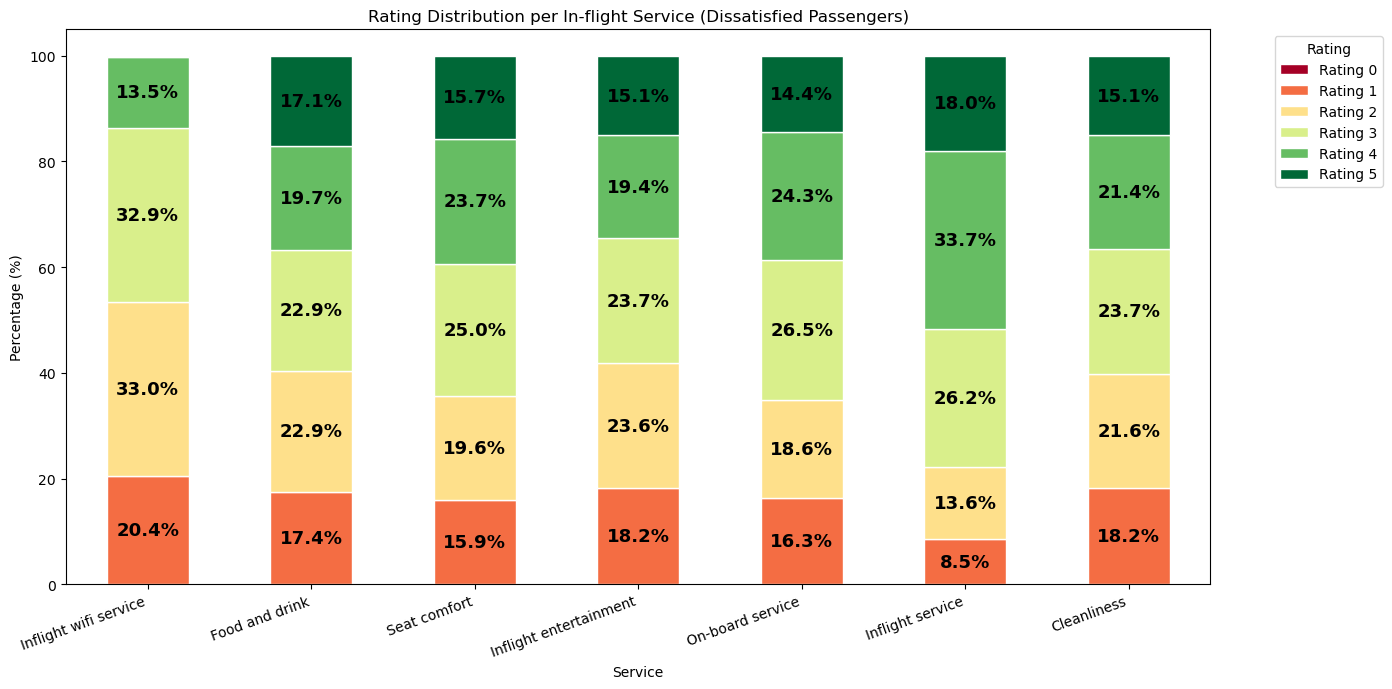

In [92]:
not_satisfied = df[df['satisfaction'] == False]

inflight_cols = [
    'Inflight wifi service', 'Food and drink', 'Seat comfort',
    'Inflight entertainment', 'On-board service', 'Inflight service', 'Cleanliness'
]

inflight_dist = not_satisfied[inflight_cols].apply(
    lambda x: x.value_counts(normalize=True).reindex(range(0, 6), fill_value=0) * 100
).T

inflight_dist.columns = ['Rating 0', 'Rating 1', 'Rating 2', 'Rating 3', 'Rating 4', 'Rating 5']

ax = inflight_dist.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 7),
    colormap='RdYlGn',
    edgecolor='white'
)

# Tambah anotasi persentase per segmen
for bar_idx, (_, row) in enumerate(inflight_dist.iterrows()):
    cumulative = 0
    for rating, value in row.items():
        if value >= 1:  # hanya tampilkan jika >= 1% biar tidak terlalu penuh
            ax.text(
                bar_idx,
                cumulative + value / 2,
                f'{value:.1f}%',
                ha='center', va='center',
                fontsize=13, fontweight='bold', color='black'
            )
        cumulative += value

plt.title('Rating Distribution per In-flight Service (Dissatisfied Passengers)')
plt.ylabel('Percentage (%)')
plt.xlabel('Service')
plt.xticks(rotation=20, ha='right')
plt.legend(title='Rating', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Ranking total dissatisfied rate (ratings 1-2) in passengers who not satisfied in inflight service:

1. Inflight wifi service (53.4%)

2. Inflight entertainment (41.8%)

3. Food and drink (40.3%)

4. Cleanliness (39.8%)

5. Seat comfort (35.5%)

6. On-board service (34.9%)

7. Inflight service (22.1%)

Inflight wifi service with total ratings 1-2 is 53.4%, but have only 13.5% that satisfied, and 32.9% normal. It shows the higher dissatisfied from antoher category in flight service. Follow by Inflight entertainment (41.8%) and Food and drink (40.3%).

> Insight

The three highest low ratings (1–2) are Inflight Wifi Service (53.4%), Inflight Entertainment (41.8%), and Food and Drink (40.3%). This shows that in-flight connectivity and entertainment are the weakest areas of inflight service.

#### 2) Statistic Inferential

In [93]:
from scipy.stats import mannwhitneyu
import numpy as np

variables = [
    'Inflight wifi service',
    'Food and drink', 
    'Seat comfort',
    'Inflight entertainment',
    'On-board service',
    'Inflight service',
    'Cleanliness'
]

for var in variables:
    satisfied = df[df['satisfaction'] == 1][var]
    not_satisfied = df[df['satisfaction'] == 0][var]
    stat, p = mannwhitneyu(satisfied, not_satisfied)
    r = 1 - (2 * stat) / (len(satisfied) * len(not_satisfied))
    print(f'{var}:')
    print(f'  p-value = {p:.4f}')
    print(f'  Effect size r = {r:.4f}')
    print()

Inflight wifi service:
  p-value = 0.0000
  Effect size r = -0.3274

Food and drink:
  p-value = 0.0000
  Effect size r = -0.2361

Seat comfort:
  p-value = 0.0000
  Effect size r = -0.4101

Inflight entertainment:
  p-value = 0.0000
  Effect size r = -0.4537

On-board service:
  p-value = 0.0000
  Effect size r = -0.3722

Inflight service:
  p-value = 0.0000
  Effect size r = -0.2973

Cleanliness:
  p-value = 0.0000
  Effect size r = -0.3450



> Insight

All service variables show p-values ≈ 0 (p < 0.05), indicating significant differences in ratings between satisfied and dissatisfied customers.

Based on the descriptive analysis, Inflight wifi service has the highest proportion of dissatisfied ratings (53.4%), followed by Inflight entertainment (41.8%) and Food and drink (40.3%). This suggests that these services are the most frequently rated poorly by dissatisfied passengers.

However, the correlation analysis shows that Inflight entertainment has the strongest relationship with overall customer satisfaction (r = -0.4537), followed by Seat comfort (r = -0.4101). In contrast, Food and drink has the weakest relationship (r = -0.2361).

This indicates that although Inflight wifi service receives the highest proportion of low ratings, Inflight entertainment and Seat comfort are more strongly associated with overall passenger satisfaction. The negative correlations across all variables indicate that dissatisfied customers tend to give lower ratings on all service aspects.

## 4. How is the dissatisfaction rate distributed among ground/airport services (Departure/Arrival time convenient, Ease of Online booking, Gate location, Online boarding, Leg room service, Baggage handling, and Checkin service)? Which ground or airport service contributes the most to passenger dissatisfaction?

#### 1) Statistic Desriptive

In [94]:
airport_cols = [
    'Departure/Arrival time convenient', 'Gate location', 'Ease of Online booking',
    'Online boarding', 'Checkin service', 'Baggage handling', 'Leg room service'
]

for col in airport_cols:
    print(f'{col}:')
    for rating in range(0, 6):
        count = len(df[df[col] == rating])
        pres = count / len(df) * 100
        print(f'  Rating {rating}: {count} ({pres:.2f}%)')
    print()

Departure/Arrival time convenient:
  Rating 0: 5300 (5.10%)
  Rating 1: 15498 (14.92%)
  Rating 2: 17191 (16.55%)
  Rating 3: 17966 (17.29%)
  Rating 4: 25546 (24.59%)
  Rating 5: 22403 (21.56%)

Gate location:
  Rating 0: 1 (0.00%)
  Rating 1: 17562 (16.90%)
  Rating 2: 19459 (18.73%)
  Rating 3: 28577 (27.50%)
  Rating 4: 24426 (23.51%)
  Rating 5: 13879 (13.36%)

Ease of Online booking:
  Rating 0: 4487 (4.32%)
  Rating 1: 17525 (16.87%)
  Rating 2: 24021 (23.12%)
  Rating 3: 24449 (23.53%)
  Rating 4: 19571 (18.84%)
  Rating 5: 13851 (13.33%)

Online boarding:
  Rating 0: 2428 (2.34%)
  Rating 1: 10692 (10.29%)
  Rating 2: 17505 (16.85%)
  Rating 3: 21804 (20.98%)
  Rating 4: 30762 (29.61%)
  Rating 5: 20713 (19.93%)

Checkin service:
  Rating 0: 1 (0.00%)
  Rating 1: 12890 (12.41%)
  Rating 2: 12893 (12.41%)
  Rating 3: 28446 (27.38%)
  Rating 4: 29055 (27.96%)
  Rating 5: 20619 (19.84%)

Baggage handling:
  Rating 0: 0 (0.00%)
  Rating 1: 7237 (6.97%)
  Rating 2: 11521 (11.09%)
 

In [95]:
not_satisfied = df[df['satisfaction'] == False]
airport_cols = [
    'Departure/Arrival time convenient', 'Gate location', 'Ease of Online booking',
    'Online boarding', 'Checkin service', 'Baggage handling', 'Leg room service'
]

for col in airport_cols:
    print(f'{col}:')
    for rating in range(0, 6):
        count = len(not_satisfied[not_satisfied[col] == rating])
        pres = count / len(not_satisfied) * 100
        print(f'  Rating {rating}: {count} ({pres:.2f}%)')
    print()

Departure/Arrival time convenient:
  Rating 0: 2780 (4.72%)
  Rating 1: 7957 (13.51%)
  Rating 2: 9534 (16.19%)
  Rating 3: 10093 (17.14%)
  Rating 4: 15640 (26.56%)
  Rating 5: 12875 (21.87%)

Gate location:
  Rating 0: 0 (0.00%)
  Rating 1: 8859 (15.05%)
  Rating 2: 10494 (17.82%)
  Rating 3: 18655 (31.68%)
  Rating 4: 14936 (25.37%)
  Rating 5: 5935 (10.08%)

Ease of Online booking:
  Rating 0: 1507 (2.56%)
  Rating 1: 10935 (18.57%)
  Rating 2: 16720 (28.40%)
  Rating 3: 16912 (28.72%)
  Rating 4: 9180 (15.59%)
  Rating 5: 3625 (6.16%)

Online boarding:
  Rating 0: 1077 (1.83%)
  Rating 1: 9219 (15.66%)
  Rating 2: 15486 (26.30%)
  Rating 3: 18845 (32.01%)
  Rating 4: 11596 (19.69%)
  Rating 5: 2656 (4.51%)

Checkin service:
  Rating 0: 1 (0.00%)
  Rating 1: 9806 (16.65%)
  Rating 2: 9640 (16.37%)
  Rating 3: 15694 (26.65%)
  Rating 4: 15692 (26.65%)
  Rating 5: 8046 (13.67%)

Baggage handling:
  Rating 0: 0 (0.00%)
  Rating 1: 5083 (8.63%)
  Rating 2: 8117 (13.79%)
  Rating 3: 157

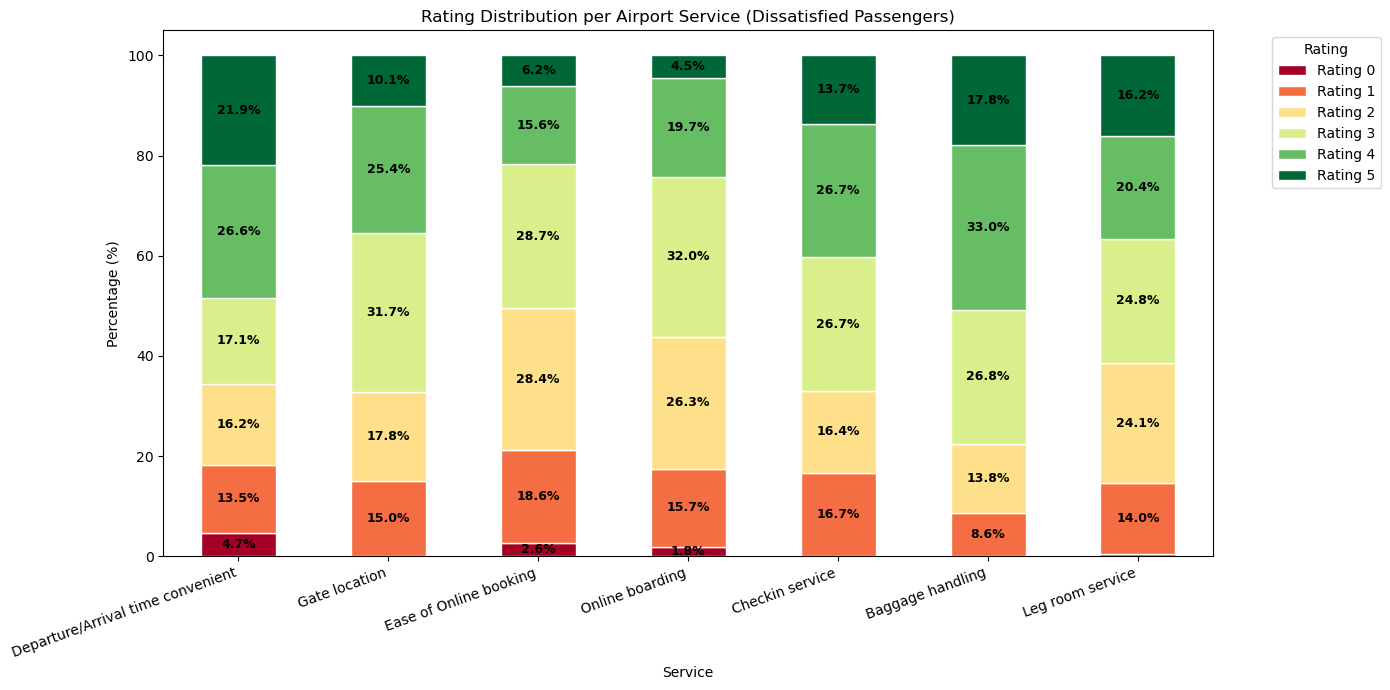

In [96]:
not_satisfied = df[df['satisfaction'] == False]

airport_cols = [
    'Departure/Arrival time convenient', 'Gate location', 'Ease of Online booking',
    'Online boarding', 'Checkin service', 'Baggage handling', 'Leg room service'
]

airport_dist = not_satisfied[airport_cols].apply(
    lambda x: x.value_counts(normalize=True).reindex(range(0, 6), fill_value=0) * 100
).T

airport_dist.columns = ['Rating 0', 'Rating 1', 'Rating 2', 'Rating 3', 'Rating 4', 'Rating 5']

ax = airport_dist.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 7),
    colormap='RdYlGn',
    edgecolor='white'
)

# Tambah anotasi persentase per segmen
for bar_idx, (_, row) in enumerate(airport_dist.iterrows()):
    cumulative = 0
    for rating, value in row.items():
        if value >= 1:  # hanya tampilkan jika >= 1% biar tidak terlalu penuh
            ax.text(
                bar_idx,
                cumulative + value / 2,
                f'{value:.1f}%',
                ha='center', va='center',
                fontsize=9, fontweight='bold', color='black'
            )
        cumulative += value

plt.title('Rating Distribution per Airport Service (Dissatisfied Passengers)')
plt.ylabel('Percentage (%)')
plt.xlabel('Service')
plt.xticks(rotation=20, ha='right')
plt.legend(title='Rating', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Ranking total dissatisfied rate (ratings 1-2) in passengers who not satisfied in airport service:

1. Ease of Online booking (47%)

2. Online boarding (42%)

3. Leg room service (38.1%)

4. Checkin service (33.1%)

5. Gate location (32.8%)

6. Departure/Arrival time convenient (29.7%)

7. Baggage handling (22.4%) 

> Insight

The three highest low ratings (1–2) are Ease of Online Booking (47%), Online Boarding (42%), and Leg Room Service (38.1%). This shows that the airline's digital services are the most problematic part of the ground and airport experience.

#### 2) Statistic Inferential

In [97]:
from scipy.stats import mannwhitneyu
import numpy as np

variables = [
    'Ease of Online booking',
    'Online boarding',
    'Leg room service',
    'Checkin service',
    'Gate location',
    'Departure/Arrival time convenient',
    'Baggage handling'
]

for var in variables:
    satisfied = df[df['satisfaction'] == 1][var]
    not_satisfied = df[df['satisfaction'] == 0][var]
    stat, p = mannwhitneyu(satisfied, not_satisfied)
    r = 1 - (2 * stat) / (len(satisfied) * len(not_satisfied))
    print(f'{var}:')
    print(f'  p-value = {p:.4f}')
    print(f'  Effect size r = {r:.4f}')
    print()

Ease of Online booking:
  p-value = 0.0000
  Effect size r = -0.2023

Online boarding:
  p-value = 0.0000
  Effect size r = -0.6260

Leg room service:
  p-value = 0.0000
  Effect size r = -0.3616

Checkin service:
  p-value = 0.0000
  Effect size r = -0.2636

Gate location:
  p-value = 0.9647
  Effect size r = 0.0002

Departure/Arrival time convenient:
  p-value = 0.0000
  Effect size r = 0.0567

Baggage handling:
  p-value = 0.0000
  Effect size r = -0.3020



> Insight

Almost all service variables show a p-value ≈ 0 (p < 0.05), indicating significant differences in ratings between satisfied and dissatisfied customers, except for Gate location which has a p-value = 0.9647, meaning the difference is not statistically significant.

Based on the effect size analysis, Online boarding has the strongest relationship with overall customer satisfaction (r = 0.6260), followed by Leg room service (r = 0.3616) and Baggage handling (r = 0.3020). In contrast, Gate location has a very weak relationship (r = 0.0002) and Departure/Arrival time convenient shows only a minimal effect (r = 0.0567).

This indicates that although some services may frequently receive complaints, Online boarding is the factor most strongly associated with overall passenger satisfaction. The correlations across most variables suggest that dissatisfied customers tend to give lower ratings on nearly all service aspects. Exceptions are seen in Departure/Arrival time convenient and Gate location, which show very small positive correlations, indicating their influence on overall satisfaction is negligible.

## 5. How is the dissatisfaction rate distributed across Departure and Arrival Delay?

### a. Departure Delay

#### 1) Statistic Desriptive

In [98]:
df['Departure Delay in Minutes'].describe()

count    103904.000000
mean         14.815618
std          38.230901
min           0.000000
25%           0.000000
50%           0.000000
75%          12.000000
max        1592.000000
Name: Departure Delay in Minutes, dtype: float64

<Axes: >

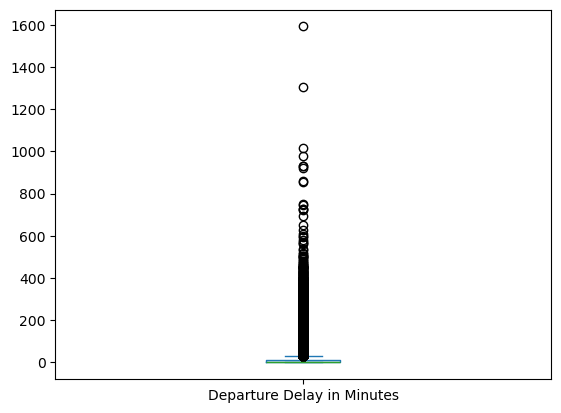

In [99]:
df['Departure Delay in Minutes'].plot.box()

It shows outliers in higher than 14 minutes are very extreme skewed.

In [100]:
DD_Satis_Yes = df[df['satisfaction'] == 1]['Departure Delay in Minutes']
DD_Satis_No = df[df['satisfaction'] == 0]['Departure Delay in Minutes']

DD_Satis_Yes.describe()

count    45025.000000
mean        12.608084
std         35.382595
min          0.000000
25%          0.000000
50%          0.000000
75%          9.000000
max       1305.000000
Name: Departure Delay in Minutes, dtype: float64

In [101]:
DD_Satis_No.describe()

count    58879.000000
mean        16.503728
std         40.191886
min          0.000000
25%          0.000000
50%          0.000000
75%         15.000000
max       1592.000000
Name: Departure Delay in Minutes, dtype: float64

The median of 0 in both groups indicates that in general, both satisfied and dissatisfied passengers did not experience any departure delay. The difference in mean of 12 vs 16 minutes is also relatively small and likely influenced by extreme values from passengers who experienced very long delays, with the maximum reaching 1,305 minutes for satisfied and 1,592 minutes for dissatisfied passengers. Therefore, it can be concluded that departure delay does not have a significant impact on customer satisfaction, and other factors play a more dominant role in determining whether a passenger is satisfied or not.

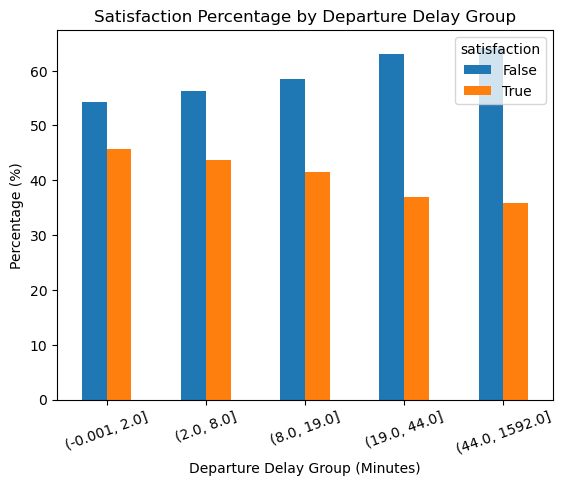

In [102]:
df['Dep_Delay_group'] = pd.qcut(df['Departure Delay in Minutes'], q=10, duplicates='drop')
Dep_Delay_Satis_pct = pd.crosstab(df['Dep_Delay_group'], df['satisfaction'], normalize='index') * 100
Dep_Delay_Satis_pct.plot(kind='bar')

plt.title('Satisfaction Percentage by Departure Delay Group')
plt.ylabel('Percentage (%)')
plt.xlabel('Departure Delay Group (Minutes)')
plt.xticks(rotation=20)
plt.show()

In [103]:
print(df['Dep_Delay_group'].value_counts().sort_index())

Dep_Delay_group
(-0.001, 2.0]     63890
(2.0, 8.0]         9759
(8.0, 19.0]       10055
(19.0, 44.0]       9996
(44.0, 1592.0]    10204
Name: count, dtype: int64


In [104]:
result = (1 - df.groupby('Dep_Delay_group')['satisfaction'].mean()) * 100
result

C:\Users\User\AppData\Local\Temp\ipykernel_21068\2385986205.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = (1 - df.groupby('Dep_Delay_group')['satisfaction'].mean()) * 100


Dep_Delay_group
(-0.001, 2.0]     54.235405
(2.0, 8.0]        56.317246
(8.0, 19.0]       58.448533
(19.0, 44.0]      63.045218
(44.0, 1592.0]    64.219914
Name: satisfaction, dtype: Float64

Rank of departure delay dissatisfaction:

1. 44 - 1,592 minutes = 64.22%

2. 19 - 44 minutes = 63.04%

3. 8 - 19 minutes = 58.44%

4. 2 - 8 minutes = 56.31%

5. 0 - 2 minutes = 54.23%

> Insight

Departure Delay distribution is not significant, that shows departure delay not primary factor of dissatisfied passenger.

#### 2) Statistic Inferential

In [113]:
stat, p = mannwhitneyu(DD_Satis_Yes, DD_Satis_No)
r = 1 - (2 * stat) / (len(DD_Satis_Yes) * len(DD_Satis_No))

print('Departure Delay in Minutes:')
print(f'  p-value = {p:.4f}')
print(f'  Effect size r = {r:.4f}')

Departure Delay in Minutes:
  p-value = 0.0000
  Effect size r = 0.0716


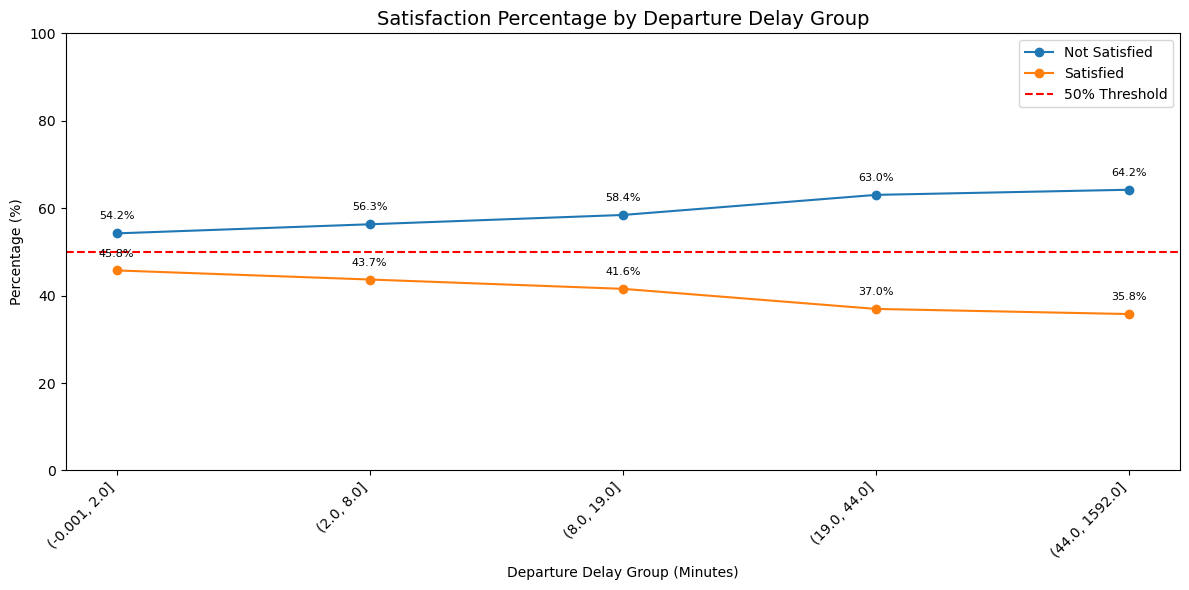

In [116]:

df['Dep_Delay_group'] = pd.qcut(df['Departure Delay in Minutes'], q=10, duplicates='drop')
Dep_Delay_Satis_pct = pd.crosstab(df['Dep_Delay_group'], df['satisfaction'], normalize='index') * 100

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
Dep_Delay_Satis_pct.plot(kind='line', marker='o', ax=ax)

# Garis 50%
ax.axhline(y=50, color='red', linestyle='--', label='50% threshold')

# Anotasi nilai
for col in Dep_Delay_Satis_pct.columns:
    for i, val in enumerate(Dep_Delay_Satis_pct[col]):
        ax.annotate(f'{val:.1f}%', 
                    (i, val), 
                    textcoords="offset points", 
                    xytext=(0, 10), 
                    ha='center', 
                    fontsize=8)

ax.set_title('Satisfaction Percentage by Departure Delay Group', fontsize=14)
ax.set_xlabel('Departure Delay Group (Minutes)')
ax.set_ylabel('Percentage (%)')

ax.set_xticks(range(len(Dep_Delay_Satis_pct.index)))
ax.set_xticklabels([str(x) for x in Dep_Delay_Satis_pct.index], rotation=45, ha='right')

ax.legend(['Not Satisfied', 'Satisfied', '50% Threshold'])
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

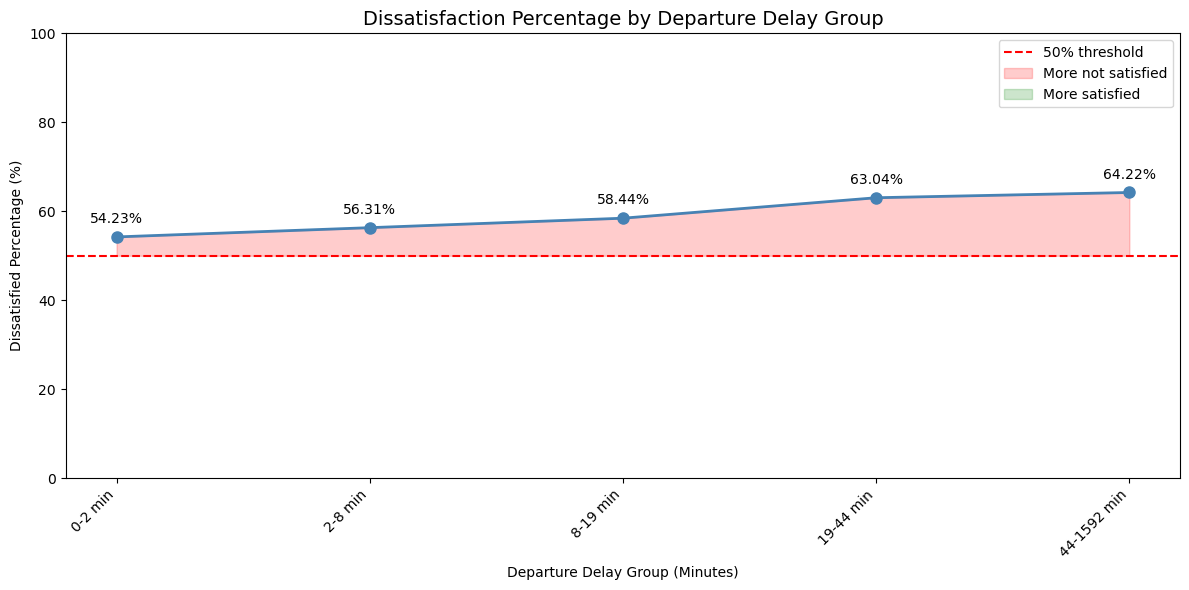

In [124]:
departure_delay = ['0-2 min', '2-8 min', '8-19 min', '19-44 min', '44-1592 min']
pct = [54.23, 56.31, 58.44, 63.04, 64.22]

plt.figure(figsize=(12, 6))
plt.plot(departure_delay, pct, marker='o', color='steelblue', linewidth=2, markersize=8)
plt.axhline(y=50, color='red', linestyle='--', label='50% threshold')
plt.fill_between(range(len(departure_delay)), pct, 50, 
                 where=[p > 50 for p in pct], 
                 alpha=0.2, color='red', label='More not satisfied')
plt.fill_between(range(len(departure_delay)), pct, 50, 
                 where=[p <= 50 for p in pct], 
                 alpha=0.2, color='green', label='More satisfied')

for i, (x, y) in enumerate(zip(departure_delay, pct)):
    plt.annotate(f'{y}%', (x, y), textcoords="offset points", xytext=(0, 10), ha='center')

plt.title('Dissatisfaction Percentage by Departure Delay Group', fontsize=14)
plt.xlabel('Departure Delay Group (Minutes)')
plt.ylabel('Dissatisfied Percentage (%)')
plt.ylim(0, 100)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

> Insight

The Mann-Whitney U test shows a p-value ≈ 0 (p < 0.05), indicating a significant difference in departure delay distribution between satisfied and dissatisfied customers. However, the effect size r = 0.0716, which is below 0.1, indicates a very weak relationship.

All delay groups, from as short as 0–2 minutes to as long as 44–1,592 minutes, still show dissatisfaction rates above 50%. This suggests that customer dissatisfaction is not entirely caused by the length of the delay. Although longer delays slightly increase dissatisfaction rates, their impact on overall satisfaction is minimal. Therefore, departure delay is not a primary driver of customer dissatisfaction, and there are other factors that play a more dominant role in shaping the overall passenger experience.

### b. Arrival Delay

#### 1) Statistic Desriptive

In [105]:
df['Arrival Delay in Minutes'].describe()

count    103904.000000
mean         15.133392
std          38.649776
min           0.000000
25%           0.000000
50%           0.000000
75%          13.000000
max        1584.000000
Name: Arrival Delay in Minutes, dtype: float64

<Axes: >

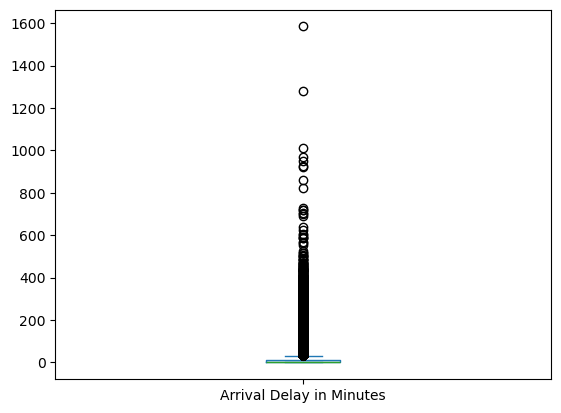

In [106]:
df['Arrival Delay in Minutes'].plot.box()

It shows outliers in higher than 14 minutes are very extreme skewed.

In [118]:
AD_Satis_Yes = df[df['satisfaction'] == 1]['Arrival Delay in Minutes']
AD_Satis_No = df[df['satisfaction'] == 0]['Arrival Delay in Minutes']

AD_Satis_Yes.describe()

count    45025.000000
mean        12.594892
std         35.917150
min          0.000000
25%          0.000000
50%          0.000000
75%          8.000000
max       1280.000000
Name: Arrival Delay in Minutes, dtype: float64

In [119]:
AD_Satis_No.describe()

count    58879.000000
mean        17.074594
std         40.508670
min          0.000000
25%          0.000000
50%          0.000000
75%         16.000000
max       1584.000000
Name: Arrival Delay in Minutes, dtype: float64

The median of 0 in both groups indicates that in general, both satisfied and dissatisfied passengers did not experience any arrival delay. The difference in mean of 12 vs 17 minutes is also relatively small and likely influenced by extreme values from passengers who experienced very long delays. Therefore, it can be concluded that arrival delay does not have a significant impact on customer satisfaction, and other factors play a more dominant role in determining whether a passenger is satisfied or not.

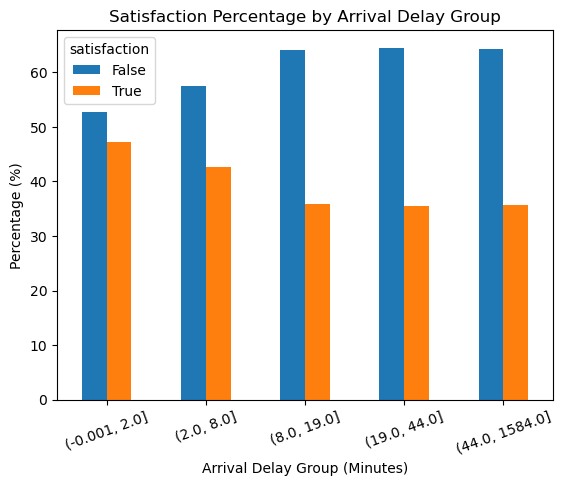

In [107]:
df['Arr_Delay_group'] = pd.qcut(df['Arrival Delay in Minutes'], q=10, duplicates='drop')
Arr_Delay_Satis_pct = pd.crosstab(df['Arr_Delay_group'], df['satisfaction'], normalize='index') * 100
Arr_Delay_Satis_pct.plot(kind='bar')

plt.title('Satisfaction Percentage by Arrival Delay Group')
plt.ylabel('Percentage (%)')
plt.xlabel('Arrival Delay Group (Minutes)')
plt.xticks(rotation=20)
plt.show()

In [108]:
print(df['Arr_Delay_group'].value_counts().sort_index())

Arr_Delay_group
(-0.001, 2.0]     62744
(2.0, 8.0]        10008
(8.0, 19.0]       10625
(19.0, 44.0]      10234
(44.0, 1584.0]    10293
Name: count, dtype: int64


In [109]:
result = (1 - df.groupby('Arr_Delay_group')['satisfaction'].mean()) * 100
result

C:\Users\User\AppData\Local\Temp\ipykernel_21068\2424416261.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = (1 - df.groupby('Arr_Delay_group')['satisfaction'].mean()) * 100


Arr_Delay_group
(-0.001, 2.0]     52.747673
(2.0, 8.0]        57.434053
(8.0, 19.0]       64.122353
(19.0, 44.0]      64.569083
(44.0, 1584.0]    64.257262
Name: satisfaction, dtype: Float64

Rank of arrival delay dissatisfaction:

1. 44 - 1,592 minutes = 64.25%

2. 19 - 44 minutes = 64.56%

3. 8 - 19 minutes = 64.12%

4. 2 - 8 minutes = 57.43%

5. 0 - 2 minutes = 52.74%

Arrival Delay distribution is not significant, that shows arrival delay not primary factor of dissatisfied passenger.

> Insight

Departure delay dissatisfaction rates range from 54.23% (0–2 min) to 64.22% (44–1,592 min), and arrival delay ranges from 52.74% (0–2 min) to 64.56% (19–44 min). The gap between the lowest and highest dissatisfaction across all delay groups is very small, showing that delay is not a significant factor in passenger dissatisfaction overall.

#### 2) Statistic Inferential

In [121]:
stat, p = mannwhitneyu(AD_Satis_Yes, AD_Satis_No)
r = 1 - (2 * stat) / (len(AD_Satis_Yes) * len(AD_Satis_No))

print('Arrival Delay in Minutes:')
print(f'  p-value = {p:.4f}')
print(f'  Effect size r = {r:.4f}')

Arrival Delay in Minutes:
  p-value = 0.0000
  Effect size r = 0.1058


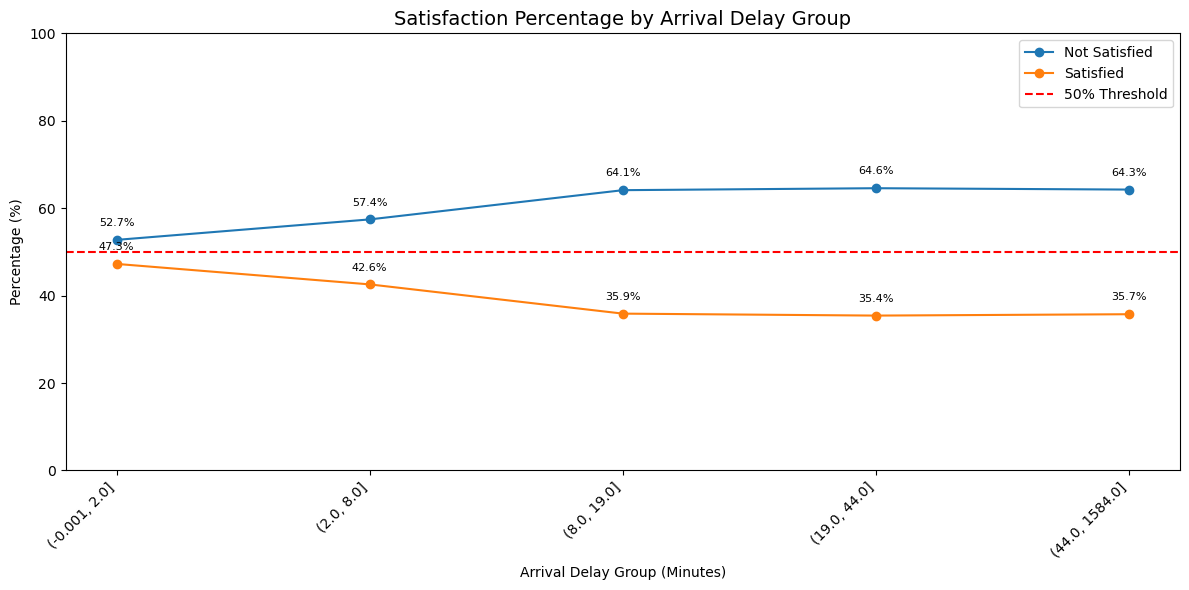

In [122]:
df['Arr_Delay_group'] = pd.qcut(df['Arrival Delay in Minutes'], q=10, duplicates='drop')
Arr_Delay_Satis_pct = pd.crosstab(df['Arr_Delay_group'], df['satisfaction'], normalize='index') * 100

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
Arr_Delay_Satis_pct.plot(kind='line', marker='o', ax=ax)

# Garis 50%
ax.axhline(y=50, color='red', linestyle='--', label='50% threshold')

# Anotasi nilai
for col in Arr_Delay_Satis_pct.columns:
    for i, val in enumerate(Arr_Delay_Satis_pct[col]):
        ax.annotate(f'{val:.1f}%', 
                    (i, val), 
                    textcoords="offset points", 
                    xytext=(0, 10), 
                    ha='center', 
                    fontsize=8)

ax.set_title('Satisfaction Percentage by Arrival Delay Group', fontsize=14)
ax.set_xlabel('Arrival Delay Group (Minutes)')
ax.set_ylabel('Percentage (%)')

ax.set_xticks(range(len(Arr_Delay_Satis_pct.index)))
ax.set_xticklabels([str(x) for x in Arr_Delay_Satis_pct.index], rotation=45, ha='right')

ax.legend(['Not Satisfied', 'Satisfied', '50% Threshold'])
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

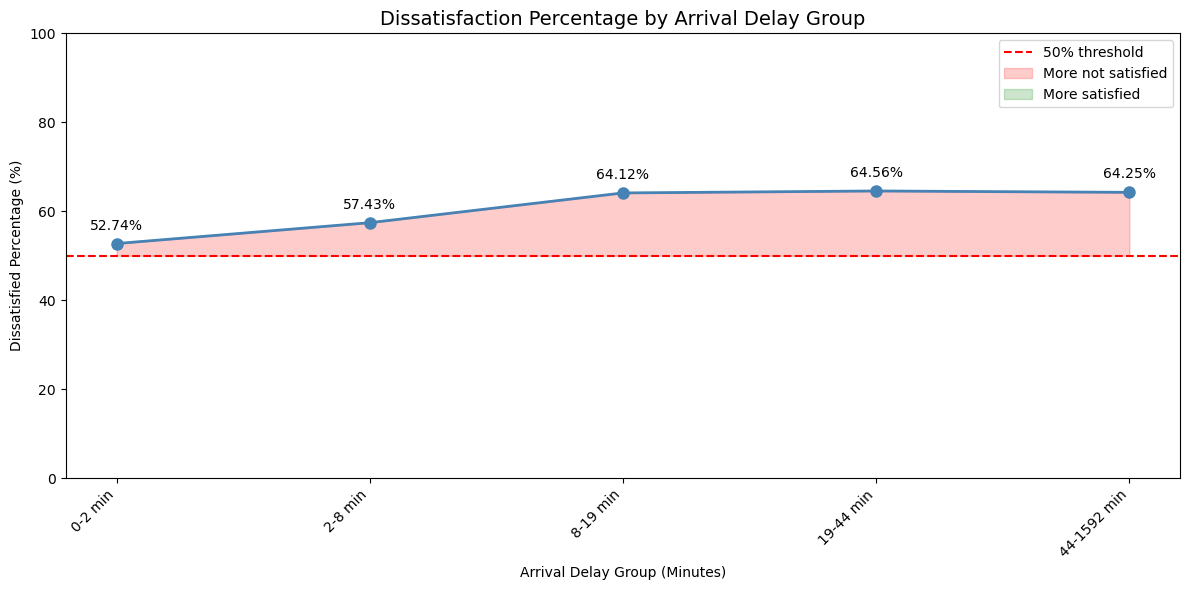

In [125]:
arrival_delay = ['0-2 min', '2-8 min', '8-19 min', '19-44 min', '44-1592 min']
pct = [52.74, 57.43, 64.12, 64.56, 64.25]

plt.figure(figsize=(12, 6))
plt.plot(arrival_delay, pct, marker='o', color='steelblue', linewidth=2, markersize=8)
plt.axhline(y=50, color='red', linestyle='--', label='50% threshold')
plt.fill_between(range(len(arrival_delay)), pct, 50, 
                 where=[p > 50 for p in pct], 
                 alpha=0.2, color='red', label='More not satisfied')
plt.fill_between(range(len(arrival_delay)), pct, 50, 
                 where=[p <= 50 for p in pct], 
                 alpha=0.2, color='green', label='More satisfied')

for i, (x, y) in enumerate(zip(arrival_delay, pct)):
    plt.annotate(f'{y}%', (x, y), textcoords="offset points", xytext=(0, 10), ha='center')

plt.title('Dissatisfaction Percentage by Arrival Delay Group', fontsize=14)
plt.xlabel('Arrival Delay Group (Minutes)')
plt.ylabel('Dissatisfied Percentage (%)')
plt.ylim(0, 100)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

## 6. How is the top 5 that dissatisfaction rate of all category and based on satisfaction level?

> Based on Category:

1. Personal travel (Type of Travel) : 89.83%
2. Eco class (Class) : 81.39%
3. Age 7–20 (Age group) : 80.37%
4. Disloyal customer (Loyalty Status) : 76.33%
5. Eco Plus class (Class) : 75.39%

> Satisfaction level category:

- Inflight services ranking:

1. Inflight wifi service : 53.4% 
2. Inflight entertainment : 41.8%
3. Food and drink : 40.3%
4. Cleanliness : 39.8%
5. Seat comfort : 35.5%

- Airport services ranking:

1. Ease of online booking — 47.0%
2. Online boarding — 42.0%
3. Leg room service — 38.1%
4. Checkin service — 33.1%
5. Gate location — 32.8%

## Conclusion

Overall, more than half of passengers (56.67%) are not satisfied with the airline's service, with the highest dissatisfaction found among Personal Travel passengers (89.83%), Eco Class (81.39%), and the 7–20 age group (80.37%). On the service side, Inflight Wifi (53.4%), Ease of Online Booking (47.0%), and Online Boarding (42.0%) received the most low ratings (1–2), indicating that digital services and in-flight connectivity are the weakest points. Delay, on the other hand, shows a very small gap across all groups and is not a significant driver of dissatisfaction. Therefore, the airline should prioritize improving wifi quality and digital components such as online booking and online boarding, as these have the lowest ratings among dissatisfied passengers. These service improvements should be focused on Personal Travel passengers and Eco Class users, who are predominantly young passengers aged 7–20 years.

# III. Algorithm

In [129]:
import pandas as pd
from itertools import combinations

# ================================================================
# 1. POPULATION
# ================================================================
population = len(df)

satisfied_sum = (
    df['satisfaction'] == True
).sum()

satisfaction_rate = (
    satisfied_sum / population * 100
)

print(f'Population                : {population}')
print(f'Satisfied Passenger       : {satisfied_sum}')
print(f'Satisfaction Rate         : {satisfaction_rate:.2f}%')


# ================================================================
# 2. DEFINE CONDITIONS
# Berdasarkan hasil insight airline passenger satisfaction
# ================================================================
conditions = {

    # ============================================================
    # CATEGORY SEGMENTATION
    # ============================================================

    # Personal Travel
    'Personal Travel' :
        df['Type of Travel'] == 'Personal Travel',

    # Eco Class
    'Eco Class' :
        df['Class'] == 'Eco',

    # Eco Plus Class
    'Eco Plus Class' :
        df['Class'] == 'Eco Plus',

    # Age 7-20
    'Age 7-20' :
        (df['Age'] >= 7) & (df['Age'] <= 20),

    # Disloyal Customer
    'Disloyal Customer' :
        df['Loyalty Status'] == False,


    # ============================================================
    # INFLIGHT SERVICES
    # ============================================================

    # Wifi Service
    'Low Wifi Service' :
        df['Inflight wifi service'] <= 2,

    # Inflight Entertainment
    'Low Inflight Entertainment' :
        df['Inflight entertainment'] <= 2,

    # Food and Drink
    'Low Food and Drink' :
        df['Food and drink'] <= 2,

    # Cleanliness
    'Low Cleanliness' :
        df['Cleanliness'] <= 2,

    # Seat Comfort
    'Low Seat Comfort' :
        df['Seat comfort'] <= 2,


    # ============================================================
    # AIRPORT SERVICES
    # ============================================================

    # Ease of Online Booking
    'Low Online Booking' :
        df['Ease of Online booking'] <= 2,

    # Online Boarding
    'Low Online Boarding' :
        df['Online boarding'] <= 2,

    # Leg Room Service
    'Low Leg Room Service' :
        df['Leg room service'] <= 2,

    # Checkin Service
    'Low Checkin Service' :
        df['Checkin service'] <= 2,

    # Gate Location
    'Low Gate Location' :
        df['Gate location'] <= 2
}


# ================================================================
# 3. CHECK POPULATION PER CONDITION
# ================================================================
tabel = []

for name, cond in conditions.items():

    total_segment = cond.sum()

    dissatisfied = (
        df[cond]['satisfaction']
        == False
    ).sum()

    dissatisfaction_rate = (
        dissatisfied / total_segment * 100
        if total_segment > 0 else 0
    )

    tabel.append({
        'Condition'             : name,
        'Population'            : total_segment,
        'Dissatisfaction Rate'  : round(dissatisfaction_rate, 2)
    })

tabel_pop = (
    pd.DataFrame(tabel)
    .sort_values(
        by='Dissatisfaction Rate',
        ascending=False
    )
)

print('\n=== Population per Condition ===')
print(tabel_pop.to_string(index=False))


# ================================================================
# 4. FIND TARGET SEGMENTS
# Fokus ke segment 10%-15% populasi
# ================================================================
lower = 0.10 * population
upper = 0.15 * population

results = []

for r in range(1, 4):

    for combo in combinations(
        conditions.items(),
        r
    ):

        names, masks = zip(*combo)

        combined_mask = masks[0]

        for m in masks[1:]:
            combined_mask = combined_mask & m

        count = combined_mask.sum()

        if lower <= count <= upper:

            dissatisfied_count = (
                df[combined_mask]['satisfaction']
                == False
            ).sum()

            dissatisfaction_rate = (
                dissatisfied_count / count * 100
            )

            results.append({

                'Combination' :
                    ' & '.join(names),

                'Population' :
                    count,

                'Dissatisfaction Rate' :
                    round(dissatisfaction_rate, 2),

                'Mask' :
                    combined_mask
            })

tabel_kombinasi = (
    pd.DataFrame(results)
    .sort_values(
        by='Dissatisfaction Rate',
        ascending=False
    )
)

print('\n=== Target Segments (10%-15% Population) ===')

print(
    tabel_kombinasi[
        [
            'Combination',
            'Population',
            'Dissatisfaction Rate'
        ]
    ].to_string(index=False)
)


# ================================================================
# 5. IMPROVEMENT FUNCTION
# Simulasi peningkatan satisfaction
# ================================================================
def calculate_improvement(
    mask,
    df,
    conversion_rate=0.15
):

    satisfied_before = (
        df['satisfaction'] == True
    ).sum()

    satisfaction_rate_before = (
        satisfied_before / len(df) * 100
    )

    dissatisfied_segment = (
        df[mask]['satisfaction']
        == False
    ).sum()

    # estimasi customer berhasil diperbaiki
    converted_customer = (
        dissatisfied_segment * conversion_rate
    )

    satisfied_after = (
        satisfied_before + converted_customer
    )

    satisfaction_rate_after = (
        satisfied_after / len(df) * 100
    )

    improvement = (
        satisfaction_rate_after
        - satisfaction_rate_before
    )

    return (
        round(improvement, 4),
        round(satisfaction_rate_after, 4)
    )


# ================================================================
# 6. CALCULATE IMPROVEMENT
# ================================================================
all_improvement = []

for row in results:

    improvement, satisfaction_after = (
        calculate_improvement(
            row['Mask'],
            df
        )
    )

    all_improvement.append({

        'Combination' :
            row['Combination'],

        'Improvement Satisfaction Rate' :
            improvement,

        'Satisfaction Rate After Program' :
            satisfaction_after
    })

tabel_improvement = (
    pd.DataFrame(all_improvement)
    .sort_values(
        by='Improvement Satisfaction Rate',
        ascending=False
    )
)

print('\n=== Improvement per Segment ===')

print(
    tabel_improvement[
        [
            'Combination',
            'Improvement Satisfaction Rate',
            'Satisfaction Rate After Program'
        ]
    ].to_string(index=False)
)


# ================================================================
# 7. FINAL ANALYSIS
# ================================================================
target_improvement = 1.5

# jumlah passenger yang ingin diperbaiki
target_passenger = round(
    target_improvement / 100 * population
)

# estimasi biaya improvement per passenger
wifi_upgrade_cost     = 19818   # Starlink Aviation 10 pesawat / 103.904 penumpang
entertainment_cost    = 15000   # estimasi flat
seat_improvement_cost = 4812    # renovasi kursi amortisasi / 103.904 penumpang
digital_service_cost  = 1925    # pengembangan sistem / 103.904 penumpang

# total = Rp 41.555 per penumpang

total_cost_per_passenger = (
    wifi_upgrade_cost +
    entertainment_cost +
    seat_improvement_cost +
    digital_service_cost
)

# total project cost
total_improvement_cost = round(
    target_passenger *
    total_cost_per_passenger,
    2
)

print(f'\n=== Final Analysis ===')

print(
    f'Target satisfaction improvement : '
    f'{target_improvement}%'
)

print(
    f'Target passenger impacted       : '
    f'{target_passenger} passengers'
)

print(
    f'Cost per passenger improvement  : '
    f'Rp{total_cost_per_passenger}'
)

print(
    f'Total improvement cost          : '
    f'Rp{total_improvement_cost}'
)

Population                : 103904
Satisfied Passenger       : 45025
Satisfaction Rate         : 43.33%

=== Population per Condition ===
                 Condition  Population  Dissatisfaction Rate
           Personal Travel       32249                 89.83
       Low Online Boarding       30625                 84.19
Low Inflight Entertainment       30129                 81.72
                 Eco Class       46745                 81.39
                  Age 7-20       11333                 80.38
           Low Cleanliness       29462                 79.47
          Low Seat Comfort       26973                 77.63
         Disloyal Customer       18981                 76.33
       Low Checkin Service       25784                 75.42
            Eco Plus Class        7494                 75.39
      Low Leg Room Service       30350                 74.86
        Low Food and Drink       34932                 68.09
          Low Wifi Service       46773                 67.24
        

> Bussiness Recomendation

1. Service improvement in Eco Class
2. Enhancement of Inflight Wifi Service and Inflight Entertainment
3. Optimization of Online Boarding and Online Booking

In [111]:
df.to_csv("train_clean.csv", index=False)